# Main script
Inferring ice sheet basal temperature with radar depth-averaged attenuation rate and basal thermal evidence

## Part (i): loading data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
# load .mat data
import scipy.io
from scipy.linalg import pinvh

import xarray as xr
# add ../ to the path
import sys
sys.path.append('../')

import src.model as model

%load_ext autoreload
%autoreload 2

data_path       = os.getenv('RAW_DATA_PATH')
param_path      = os.getenv('PARAM_PATH')
output_path     = os.getenv('INFERENCE_READY_DATA_PATH')
posterior_path   = os.getenv('POSTERIOR_PATH')
folder = data_path
# ------------------------------------------------- LOAD SIMULATION DATA -------------------------------------------------
# get the DATA_PATH from the environment variable
XY_train_filename    = "train_data.npz"
XY_valid_filename    = "validation_data.npz"
XY_test_filename     = "test_data.npz"
H_filename           = 'H_gridded.mat'
Y_obs_filename       = "Ns_obs_gridded.mat"
mask_filename        = 'training_mask.mat' 
model_bound_filename = 'training_mask_domain_continuous.mat'
# also the mean and std of Eb for reverse standardization
Eb_mean_filename     = 'trainingAll_Eb_sim_mean.mat'
Eb_std_filename      = 'trainingAll_Eb_sim_std.mat'
# also the mean and std of Ns for standardization of observed data
Ns_mean_filename     = 'trainingAll_Ns_sim_mean_masked.mat'
Ns_std_filename      = 'trainingAll_Ns_sim_std_masked.mat'
# others
coord_filename       = "trainingAll_image_coord.mat"

# preprocessing parameter file: read the csv file
preprocess_param = pd.read_csv(param_path, index_col=0)
Eb_standardize_epsilon = preprocess_param['Eb_standardization_epsilon'].values[0]
Ns_standardize_epsilon = preprocess_param['Ns_standardization_epsilon'].values[0]
print("Eb_standardize_epsilon:", Eb_standardize_epsilon)
print("Ns_standardize_epsilon:", Ns_standardize_epsilon)


flight_mask_data = scipy.io.loadmat(folder + mask_filename) # this is the flightline mask
H_data           = scipy.io.loadmat(folder + H_filename)
model_bound_data = scipy.io.loadmat(folder + model_bound_filename) # this is model domain mask
coord_data       = scipy.io.loadmat(folder + coord_filename)
# standardization data for Eb
Eb_mean          = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std           = scipy.io.loadmat(folder + Eb_std_filename)

# load
Eb_standardized_train = np.load(output_path + XY_train_filename)['Eb_train']
Ns_standardized_train = np.load(output_path + XY_train_filename)['Ns_train']
Eb_standardized_valid = np.load(output_path + XY_valid_filename)['Eb_validation']
Ns_standardized_valid = np.load(output_path + XY_valid_filename)['Ns_validation']
Eb_standardized_test  = np.load(output_path + XY_test_filename)['Eb_test']
Ns_standardized_test  = np.load(output_path + XY_test_filename)['Ns_test']
# replace nan by 0
Eb_mean = np.nan_to_num(Eb_mean['Eb_mean'], nan=0.0).flatten()
Eb_std  = np.nan_to_num(Eb_std['Eb_std'], nan=0.0).flatten()

# load model boundary
model_bound_data_ori = model_bound_data['in_domain_mask'].astype(bool)

x_coord = coord_data['training_coord'][0][0][0]
y_coord = coord_data['training_coord'][0][0][1]
extent = np.array([x_coord.min(), x_coord.max(), y_coord.max(), y_coord.min()])/1e3 # convert to km (left, right, bottom, top), imshow by default is inverted in y-axis

# -------------------------------------------------- LOAD OBSERVATION DATA --------------------------------------------------
Y_obs_data   = scipy.io.loadmat(folder + Y_obs_filename)
# standardization data for Ns
Ns_mean_data = scipy.io.loadmat(folder + Ns_mean_filename)
Ns_std_data  = scipy.io.loadmat(folder + Ns_std_filename)
Ns_mean = Ns_mean_data['Ns_mean_masked']
Ns_std = Ns_std_data['Ns_std_masked']  

Y_obs_data     = Y_obs_data['atten_rate_grid']
atten_rate_avg = Y_obs_data['atten_avg'][0][0]

# apply flightline masking to the standardization mean and std
flight_mask = flight_mask_data['mask']
flight_mask_bool = flight_mask.astype(bool)
Ns_mean_masked = Ns_mean.copy()
Ns_mean_masked[~flight_mask_bool] = 0 # set the mean to 0
Ns_std_masked = Ns_std.copy()
Ns_std_masked[~flight_mask_bool] = 1 # set the std to 1

Ns_mean_masked = Ns_mean_masked.flatten()   
Ns_std_masked  = Ns_std_masked.flatten()

print('Shape of Eb_standardized_train:', Eb_standardized_train.shape)
print('Shape of Ns_standardized_train:', Ns_standardized_train.shape)
print('Shape of domain mask:', model_bound_data_ori.shape)
print('Shape of flight mask:', flight_mask_bool.shape)


/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Eb_standardize_epsilon: 1287.4819202075
Ns_standardize_epsilon: 0.262291780650704
Shape of Eb_standardized_train: (256, 256, 1, 937)
Shape of Ns_standardized_train: (256, 256, 1, 937)
Shape of domain mask: (256, 256)
Shape of flight mask: (256, 256)


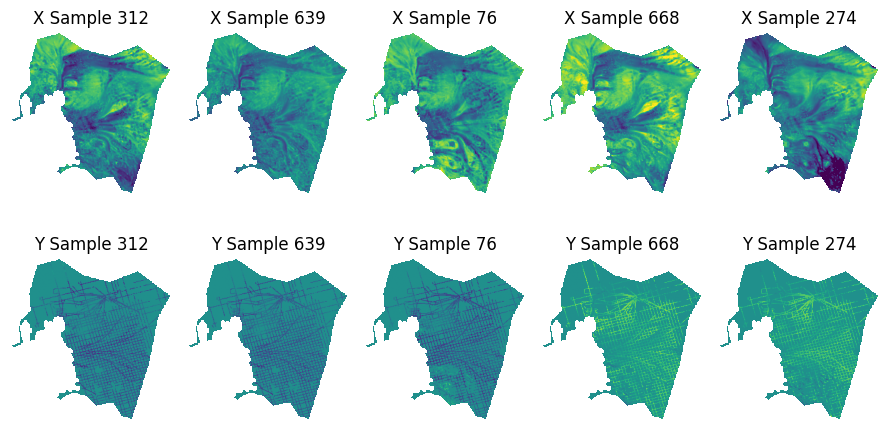

In [2]:
# initialize the model object
md = model.model(extent=extent, coord=(x_coord, y_coord))

# load training data
# first combine all so that our PCA is operated on the whole dataset
Eb_standardized_all = np.concatenate([Eb_standardized_train, 
                                      Eb_standardized_valid, 
                                      Eb_standardized_test], 
                                      axis=3)
Ns_standardized_all = np.concatenate([Ns_standardized_train, 
                                      Ns_standardized_valid, 
                                      Ns_standardized_test], 
                                      axis=3)
md.load_sim_data(Eb_standardized_all, Ns_standardized_all, 
                 domain_mask=model_bound_data_ori, 
                 flight_mask=flight_mask_bool, 
                 show_plot=True)

md.load_standardization_data(X_mean=Eb_mean, X_std=Eb_std,
                             Y_mean=Ns_mean_masked, Y_std=Ns_std_masked,
                             X_epsilon=Eb_standardize_epsilon, Y_epsilon=Ns_standardize_epsilon)

## Part (ii): inspecting data dimension with PCA

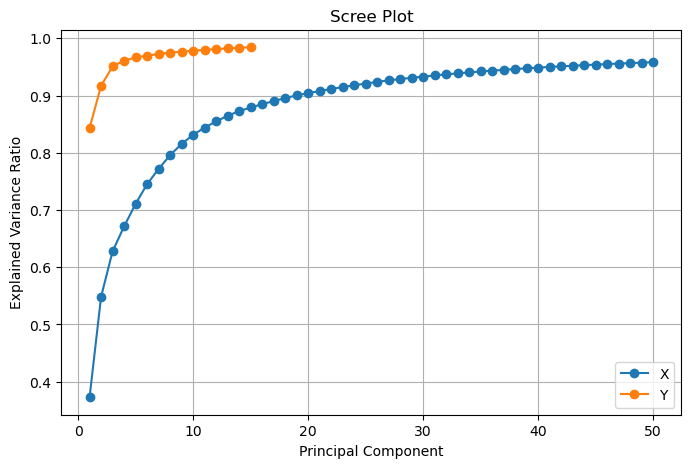

In [5]:
md.pca_scree(n_component_x=50, n_component_y=15)

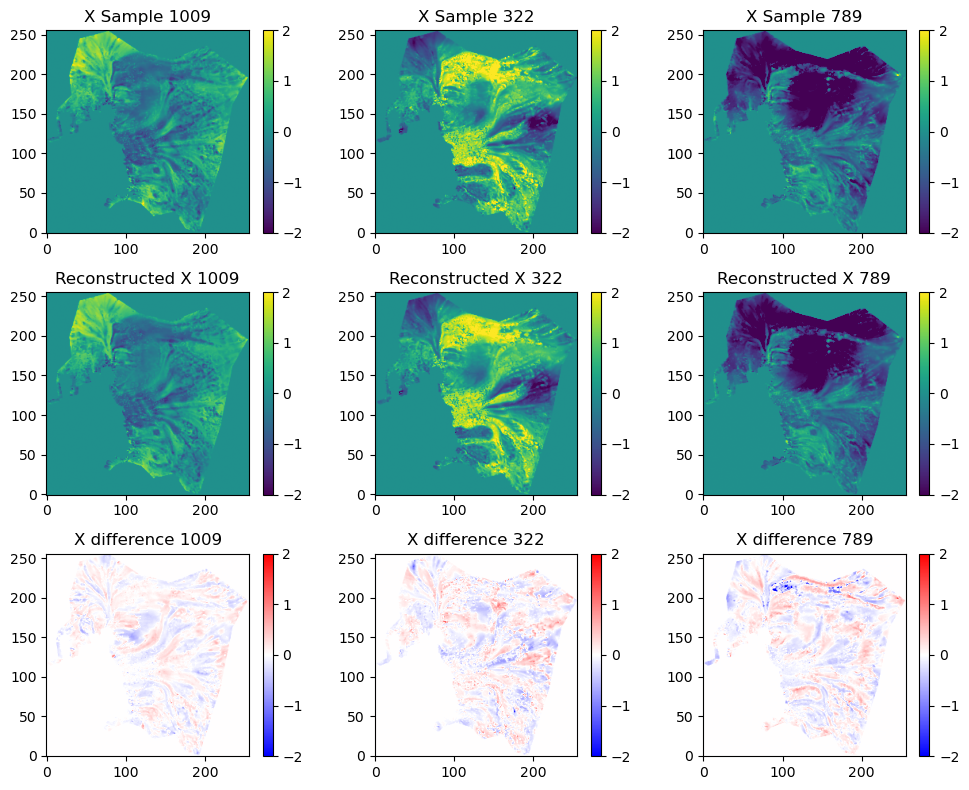

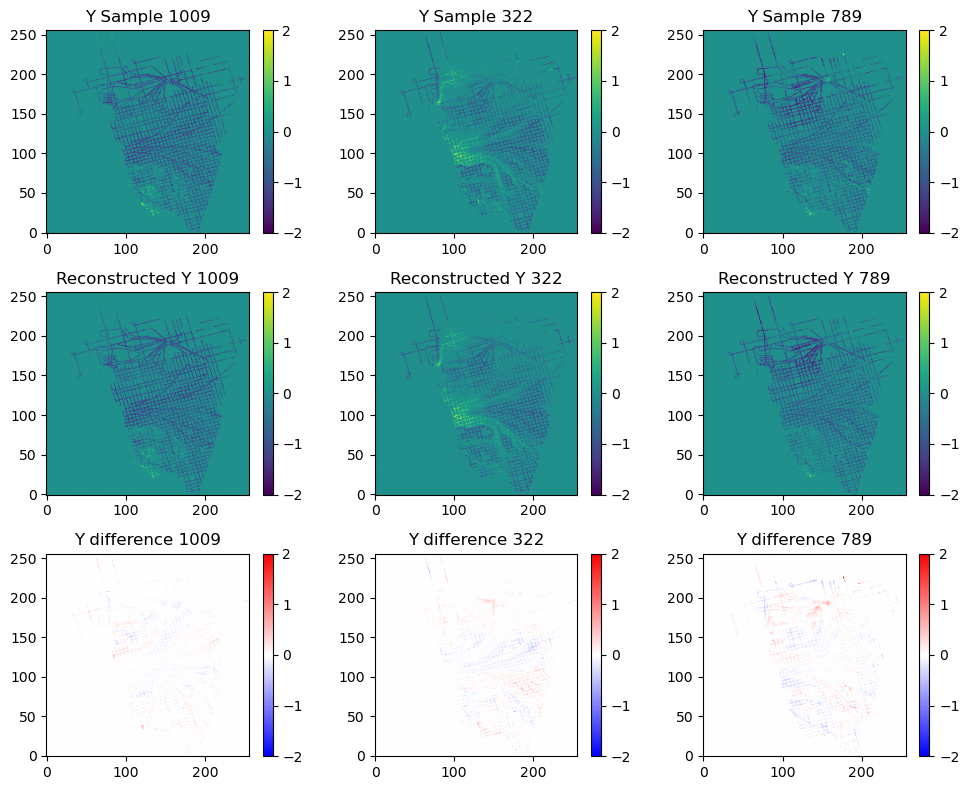

In [7]:
md.pca_recon_inspection(n_component_x=50, n_component_y=15)

## Part (iii): Dimension reduction and derive the informative prior

Let $E_b \in \mathbb{R}^{d}$ and $N_a \in \mathbb{R}^{d}$ denote the original dimension in the physical space, 
where $d$ is the shared physical dimension. The truncated PCA retains the leading 
$r_{E} \ll d$ and $r_{N} \ll d$ principal components, defining the projection maps:
$$V_{E_b} \in \mathbb{R}^{d \times r_E}, \qquad V_{N_a} \in \mathbb{R}^{d \times r_N}$$
whose columns are the leading right singular vectors of the respective centered data matrices. 
The latent representations are then:

$$E_b^* = V_{E_b}^\top E_b \in \mathbb{R}^{r_E}, \qquad N_a^* = V_{N_a}^\top N_a \in \mathbb{R}^{r_N}$$

so that the joint latent vector $\mathbf{z} = [E_b^{*\top}, N_a^{*\top}]^\top \in \mathbb{R}^{r}$ 
lives in a space of total dimension $r = r_E + r_N$.

Gaussian Mixture Model is a parametric model that approximates a complex distribution with a mixture of Gaussians, where individual Gaussian distributions are weighted using Expectation Maximization. The joint distribution of depth-averaged enthalpy and basal enthalpy is
\begin{equation}
    P(E_b^*, N_a^*) = \sum_{k=1}^N \pi^k \,\mathcal{N}^k(E_b^*, N_a^*|\mu_{E_b,N_a^*}^k, \Sigma_{E_b^*,N_a^*}^k)
\end{equation}
where the superscript $k$ denotes the $k$-th Gaussian and $\pi$ is the weight. The marginal distribution, conditioned by a depth-averaged enthalpy, is also a linear combination of the individual Gaussian distributions
\begin{equation}
    P(E_b^*| N_a^*) = \sum_{k=1}^N \pi_{E_b^*|N_a^*}^k \,\mathcal{N}^k(E_b^*|\mu_{E_b^*|N_a^*}^k, \Sigma_{E_b^*|N_a^*}^k)
\end{equation}
with the updated weights 
\begin{equation}
    \pi_{E_b^*|N_a^*}^k = \frac{\mathcal{N}^k(N_a^*|\mu_{N_a^*}^k, \Sigma_{N_a^*}^k)}{\sum_{l=1}^N \mathcal{N}^l(N_a^*|\mu_{N_a^*}^l, \Sigma_{N_a^*}^l)}
\end{equation}
and mean and covariance following the marginal distribution of multivariate normal distribution
\begin{align}
    \mu_{E_b^*|N_a^*} & = \mu_{E_b^*} + \Sigma_{N_a^*, E_b^*}\Sigma_{N_a^*,N_a^*}^{-1}(N_a^* - \mu_{N_a^*})\\
    \Sigma_{E_b^*|N_a^*} & = \Sigma_{E_b^*,E_b^*}-\Sigma_{E_b^*, N_a^*}\Sigma_{N_a^*, N_a^*}^{-1}\Sigma_{E_b^*, N_a^*}
\end{align}

In [3]:
from src.validation import bayesian_information_criterion

# reduce dim with PCA. 
md.find_reduction_model_pca(n_component_x=50, n_component_y=15)

# load specifically the train, validation, and test (pre-split) data and apply the fitted PCA
md.load_split_data(X_train=Eb_standardized_train, Y_train=Ns_standardized_train,
                   X_validation=Eb_standardized_valid, Y_validation=Ns_standardized_valid,
                   X_test=Eb_standardized_test, Y_test=Ns_standardized_test)

# y_train = md.XY_train[:, md.y_indices]
# x_train = md.XY_train[:, md.x_indices]

# # Run Bayesian Information Criterion (BIC) sweep to find the optimal number of GMM components
# gmm_components = np.linspace(1, 20, 20, dtype=int)
# bic_list = []
# kln_list = []
# neg2L_list = []
# for n_components in gmm_components:
#     md.train_gmm_XY(n_components=n_components)
#     bic, kln, neg2L = bayesian_information_criterion(md, x_train, y_train, n = md.n_samples_train)
#     bic_list.append(bic)
#     kln_list.append(kln)
#     neg2L_list.append(neg2L)
#     print("n_components:", n_components, "BIC:", bic)

# plt.figure(figsize=(15, 6))
# plt.subplot(1,2,1)
# plt.plot(gmm_components, bic_list, marker='o')
# plt.xlabel('Number of GMM Components')
# plt.ylabel('Bayesian Information Criterion (BIC)')
# plt.title('BIC vs Number of GMM Components')
# plt.grid()
# # plot the component
# plt.subplot(1,2,2)
# plt.plot(gmm_components, kln_list, marker='o', label='k*ln(n)')
# plt.plot(gmm_components, neg2L_list, marker='o', label='-2*L')
# plt.xlabel('Number of GMM Components')
# plt.ylabel('Component Values')
# plt.title('BIC Components vs Number of GMM Components')
# plt.legend()
# plt.grid()
# plt.show()

PCA model saved to self.pca_x and self.pca_y.
Shape of XY_train: (937, 65)
Shape of XY_validation: (0, 65)
Shape of XY_test: (105, 65)


GMM training completed in 1.86 seconds.


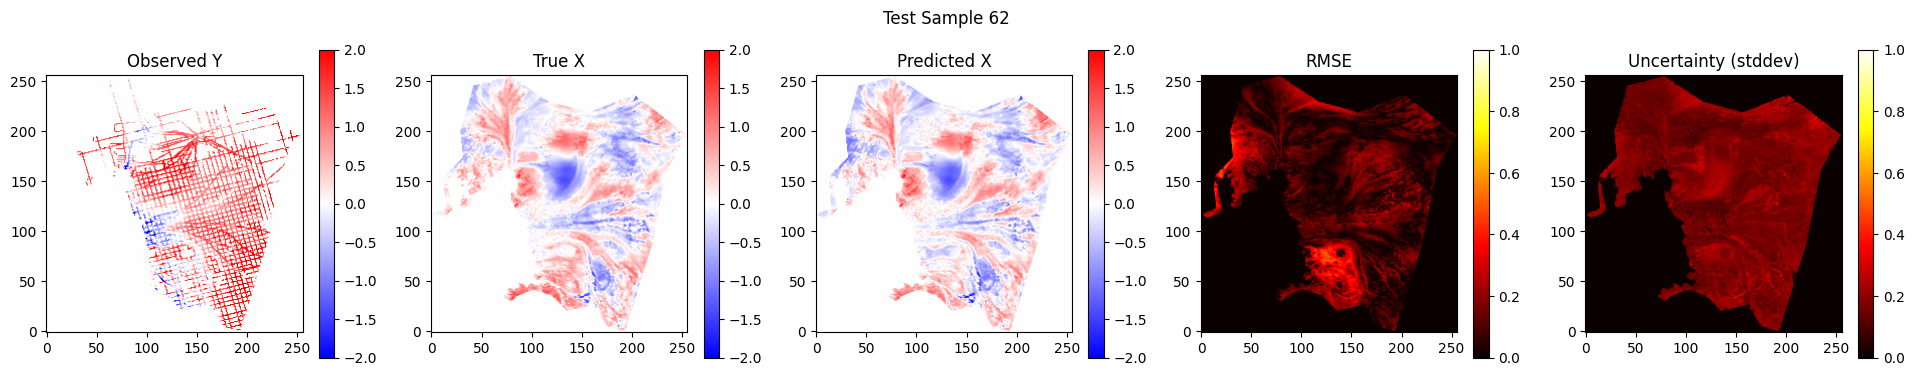

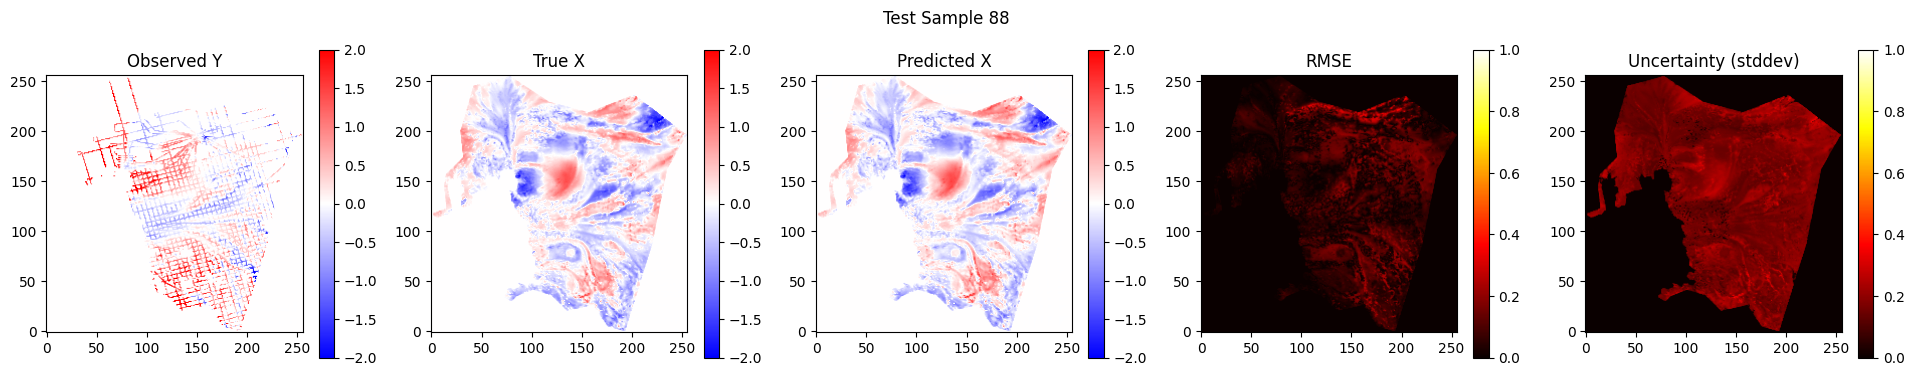

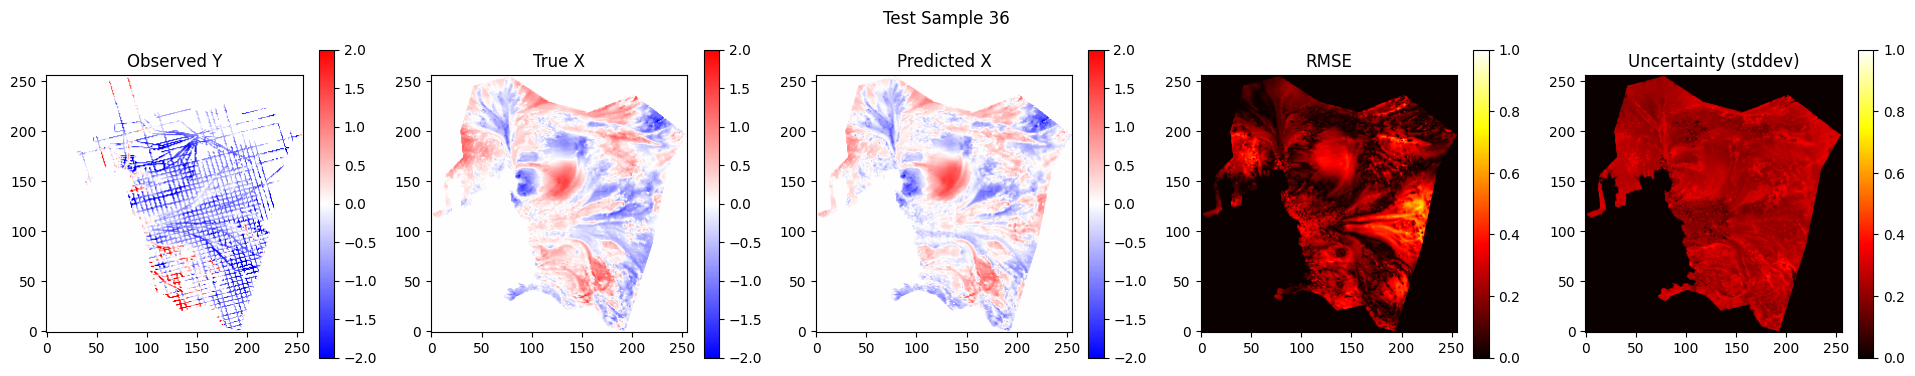

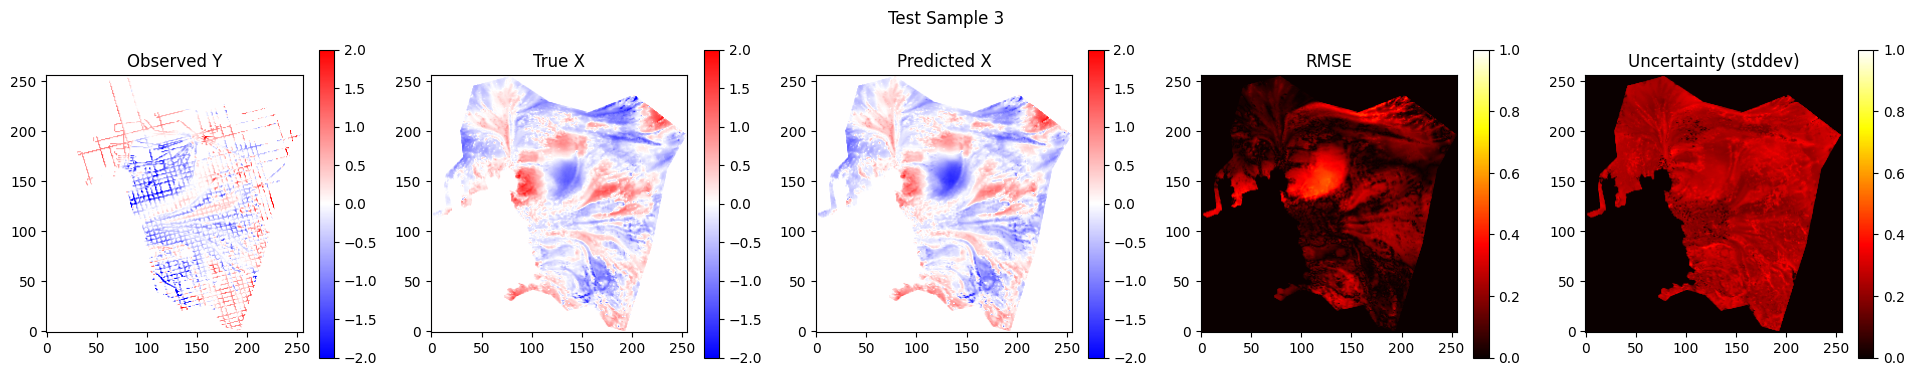

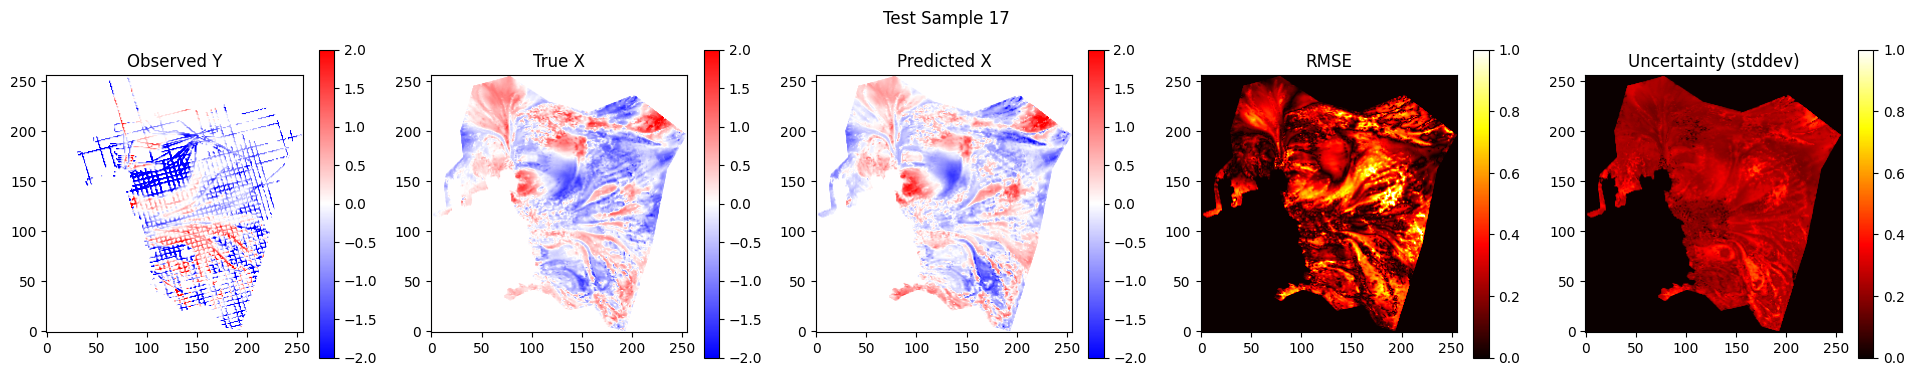

In [10]:

# based on the BIC sweep plot
n_optimal = 5
md.train_gmm_XY(n_components=n_optimal)
md.plot_gmm_samples_pca(n_samples=5)

shape of Y_obs: (256, 256)


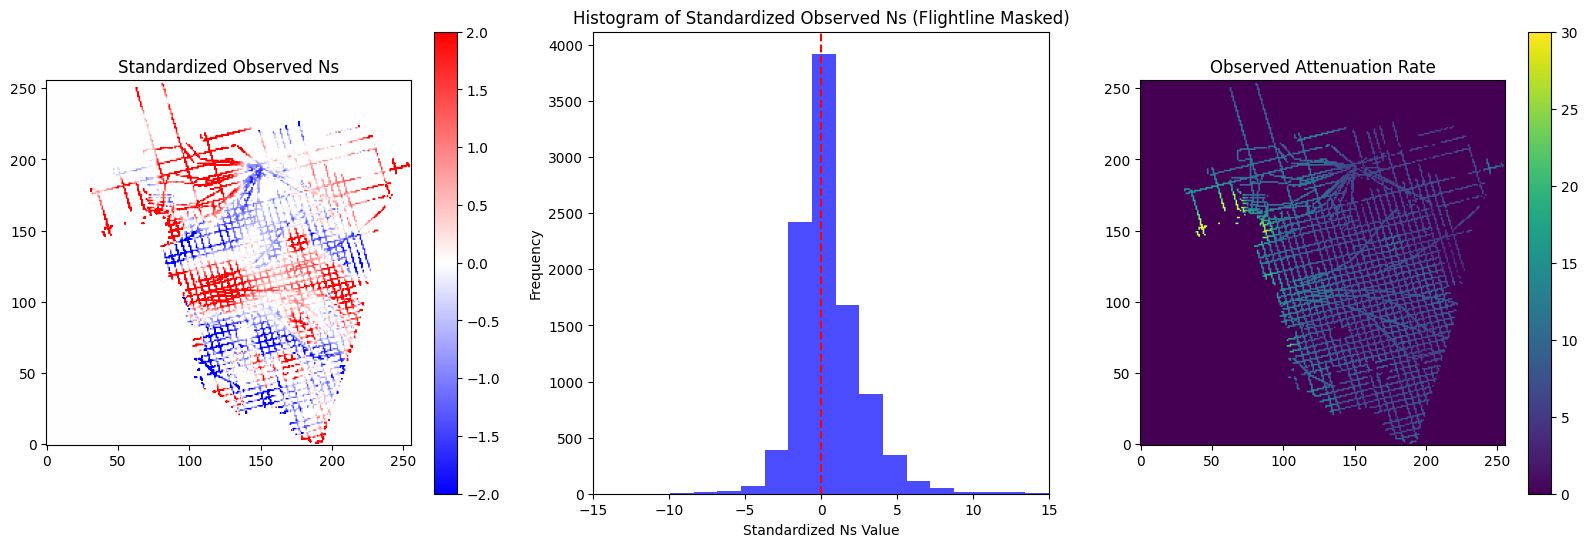

In [11]:
md.load_obs_data(atten_rate_avg)


We propose a simple optimization framework to ensure that the reconstruction error of the observed attenuation rate is minimized while its latent representation remains in distribution to its distribution learned from the thermal simulation ensemble. This effectively regularizes the observed $N_a^*$ and avoid overfitting to the principal components:
\begin{equation}
\hat{N}_a^* = \arg \min_{N_a^*}\,\, \frac{1}{\beta N} \|N_{\text{ao}} - VE_{a,\text{orig}}^*\|_2^2- \log P(N_a^*)
\end{equation}
To construct the distribution of the observational uncertainty in the latent space, we assume that it follows a multivariate gaussian distribution, $P(N_{ao}^*) = \mathcal{N}(\hat{N}_a^*, \Sigma_{N_{ao}^*})$. We want the support of $P(N_{ao}^*)$ to encompass the residual in the latent space. Here let us define the residual in the latent space as the residual of the reconstructed attenuation rate projected back to the latent space:
\begin{equation}
    R^* = V_{N_{a}}^T (N_{ao} - V_{N_a}\hat{N}_a^*)
\end{equation}
and therefore we propose that the covariance matrix in the latent space as
\begin{equation}
    \Sigma_{N_{ao}^*} = \nu_1 R^* (R^*)^T + \nu_2 \,\text{diag}(\lambda_i)
\end{equation}
where $\lambda_i$ are the eigenvalues computed from the singular values of SVD. The $R^*(R^*)^T$, a rank-1 matrix, represents the uncertainty of our observed attenuation rate in the projected subspace, and it is mixed with the covariance structure from the simulation ensemble via the eigenvalues. Here we assume $\nu_1 = \nu_2$ and thus treating the two sources of attenuation rate uncertainty as independent.

Density at init: [5.57593852e-07]
 Likelihood: 96876.243, Prior: 14.400
 Likelihood: 307831.423, Prior: 158.665
 Likelihood: 89161.641, Prior: 18.004
 Likelihood: 88025.011, Prior: 20.089
 Likelihood: 82893.819, Prior: 57.066
 Likelihood: 80955.810, Prior: 91.314
 Likelihood: 79103.528, Prior: 150.630
 Likelihood: 78142.181, Prior: 143.211
 Likelihood: 77616.110, Prior: 131.636
 Likelihood: 77486.264, Prior: 126.938
 Likelihood: 77265.696, Prior: 121.330
 Likelihood: 77203.706, Prior: 122.462
 Likelihood: 77182.434, Prior: 123.011
 Likelihood: 77172.708, Prior: 124.404
 Likelihood: 77168.478, Prior: 125.265
 Likelihood: 77167.539, Prior: 125.011
 Likelihood: 77166.371, Prior: 124.668
 Likelihood: 77164.024, Prior: 124.071
 Likelihood: 77160.290, Prior: 123.290
 Likelihood: 77158.092, Prior: 122.856
 Likelihood: 77156.551, Prior: 122.972
 Likelihood: 77156.251, Prior: 123.066
 Likelihood: 77156.205, Prior: 123.094
 Likelihood: 77156.206, Prior: 123.093
 Likelihood: 77156.218, Prior: 123

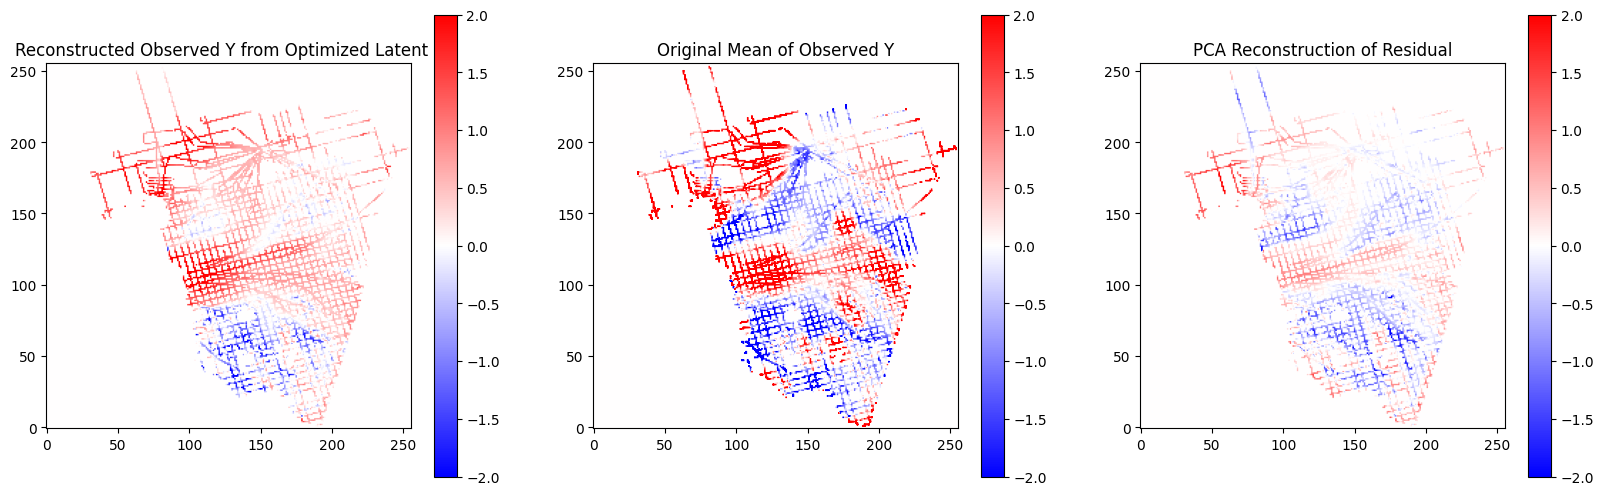

first 5x5 block of cov_obs_latent:
[[ 3.49958769e+04  4.65580698e-04  9.63199464e-05 -7.88274538e-04]
 [ 4.65580698e-04  3.04983836e+03  5.76054983e-03 -4.71438671e-02]
 [ 9.63199464e-05  5.76054983e-03  1.40931144e+03 -9.75318515e-03]
 [-7.88274538e-04 -4.71438671e-02 -9.75318515e-03  4.21227342e+02]]
min eigenvalue: 41.480977449008975
conditioned indices are:  [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


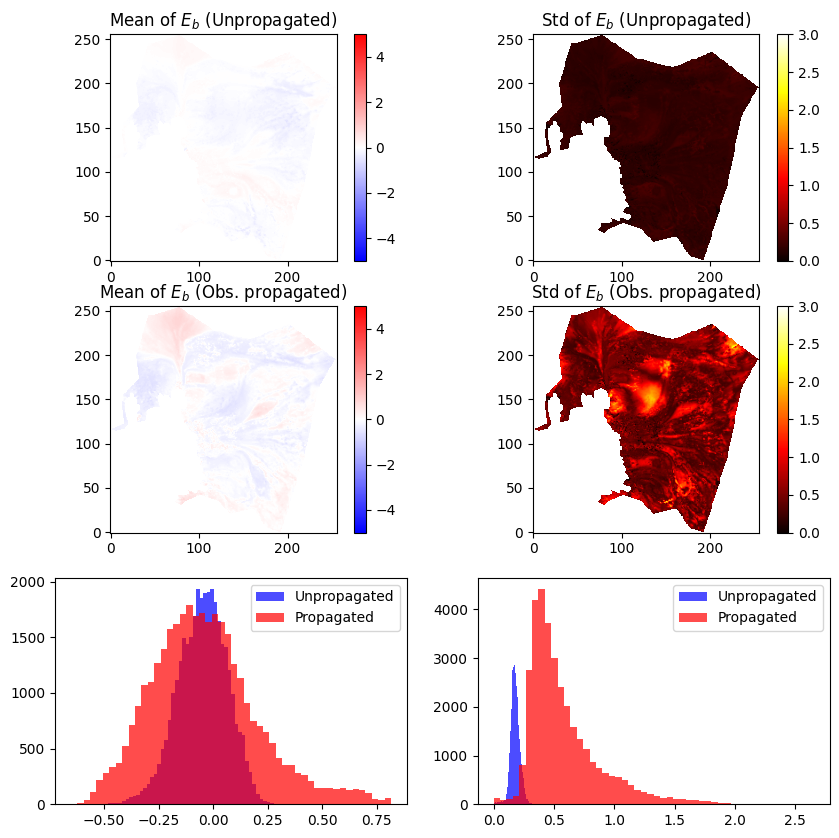

In [12]:
# the beta_prior comes from the L-curve plot
beta_prior = 0.00001
lambda1, lambda2 = 1,5
md.derive_prior(beta=beta_prior, lambda1=lambda1, lambda2=lambda2)

## Part (iv): loading basal thermal evidence

What are the basal thermal evidence? We consider the thawed evidence and frozen evidence. To identify thawed basal evidence, in the drainage basin for Thwaites Glacier, we consider both specularity and relative reflectivity; in the drainage basin for Pine Island Glacier, we only consider the bed relative reflectivity. For the frozen base evidence, we only consider bed relative reflectivity.


We model the bed relative reflectivity with dielectrics from various possible substrates. Here we assume that both ice and the substrate are non-magnetic, and that the radiowave propagates through the ice-bed interface at normal insidence. We will use subscript "1" and "2" to denote the materials where "2" is underneath "1". The real amplitude reflection coefficient $r_{12}$ is
\begin{equation}
    r_{12} = \sqrt{\frac{(\alpha_1 - \alpha_2)^2 + (\beta_1 - \beta_2)^2}{(\alpha_1+\alpha_2)^2 + (\beta_1+\beta_2)^2}}
\end{equation}
where $\alpha$ is the phase constant and $\beta$ is the attenuation constant, and are defined as
\begin{align}
    \alpha & = \omega \left[\frac{\mu_0\mu_r\epsilon_0\epsilon_r}{2}\left(\sqrt{1 + \frac{\sigma^2}{(\epsilon_0 \epsilon_r)^2 \omega^2}}  \right) + 1  \right]^{1/2} \\
    \beta & = \omega \left[\frac{\mu_0\mu_r\epsilon_0\epsilon_r}{2}\left(\sqrt{1 + \frac{\sigma^2}{(\epsilon_0 \epsilon_r)^2 \omega^2}}  \right) - 1  \right]^{1/2}
\end{align}
Here $\mu_0 = 1.256637\times10^{-6} H m^{-1}$ is magnetic permeability in free space and $\mu_r=1$; $\epsilon_0 = 8.854187\times10^{-12} \, s^2 H^{-1} m^{-1}$ is dielectric permittivity in free space and $\epsilon_r$ is relative permittivity; $\sigma$ is electrical conductivity. $\omega = 2\pi f$ is the angular frequency of the radiowave with linear frequency $f$. We will "a" to denote air, "i" to denote ice, and "b" to denote the substrate. Therefore we can write the relative bed reflectivity $R_b$ in decibel convention as 
\begin{equation}
    R_b = 10\log_{10}(r_{ai}^2) - 10\log_{10}(r_{ib}^2)
\end{equation}
Fig.~\ref{fig:reflectivity} shows the bed relative reflectivity across various substrate materials across the bandwidth of both PASIN and HiCARS systems. The plot shows that certain porous sedimentary substrates such as Fairbanks silt, saline basal ice, and sandy till can produce high relative bed reflectivity. To avoid false positive in identifying basal water, it is therefore necessary to either make conservative threshold of bed reflectivity, or to couple with other independent radar or geophysical evidence. For ASE, we take advantage of pre-existing specularity dataset around Thwaites glacier and require that
- For regions where specularity is computed, the basal water exists when both specularity (S) is larger than 0.3 (to be consistent with Winnie's paper) and bed relative reflectivity is larger than 10 dB.
- For regions where specularity is not computed, the basal water exists when the bed reflectivity is larger than 15 dB.
Identifying frozen base is less prone to false positive since the real permittivity and electrical conductivity of either subglacial freshwater or seawater are significantly larger than those of the glacier ice. Therefore our conservative threshold for the frozen base is where bed relative reflectivity is less than -30 dB, lower than any of the modeled subglacial substrates

In [13]:
from src.ice import compute_pmp

# load the thawed base and frozen base data
frozen_base_filename = folder + "../../basal-frozen-mask/frozen_mask.mat"
thawed_base_filename = folder + "../../basal-water-mask/water_mask.mat"
frozen_mask = scipy.io.loadmat(frozen_base_filename)['frozen_mask']
thawed_mask = scipy.io.loadmat(thawed_base_filename)['water_mask']
frozen_mask_data = frozen_mask['data'][0][0]
thawed_mask_data = thawed_mask['data'][0][0]

Eb_mean_data = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std_data = scipy.io.loadmat(folder + Eb_std_filename)
# replace nan by 0
Eb_mean_data = np.nan_to_num(Eb_mean_data['Eb_mean'], nan=0.0)
Eb_std_data = np.nan_to_num(Eb_std_data['Eb_std'], nan=0.0)

# compute pmp
H = H_data['H_struct']['H'][0][0].flatten()
X = H_data['H_struct']['X'][0][0].flatten()
Y = H_data['H_struct']['Y'][0][0].flatten()
pmp = compute_pmp(H)

# into a vector
Eb_mean_data = Eb_mean_data.flatten()
Eb_std_data = Eb_std_data.flatten()
frozen_mask_data = frozen_mask_data.flatten()
thawed_mask_data = thawed_mask_data.flatten()

# set fractional area to 1 for all locations (assumption for now, can be relaxed later)
thawed_fractional_area = np.zeros_like(thawed_mask_data)
frozen_fractional_area = np.zeros_like(frozen_mask_data)
thawed_fractional_area[thawed_mask_data == 1] = 1.0
frozen_fractional_area[frozen_mask_data == 1] = 1.0

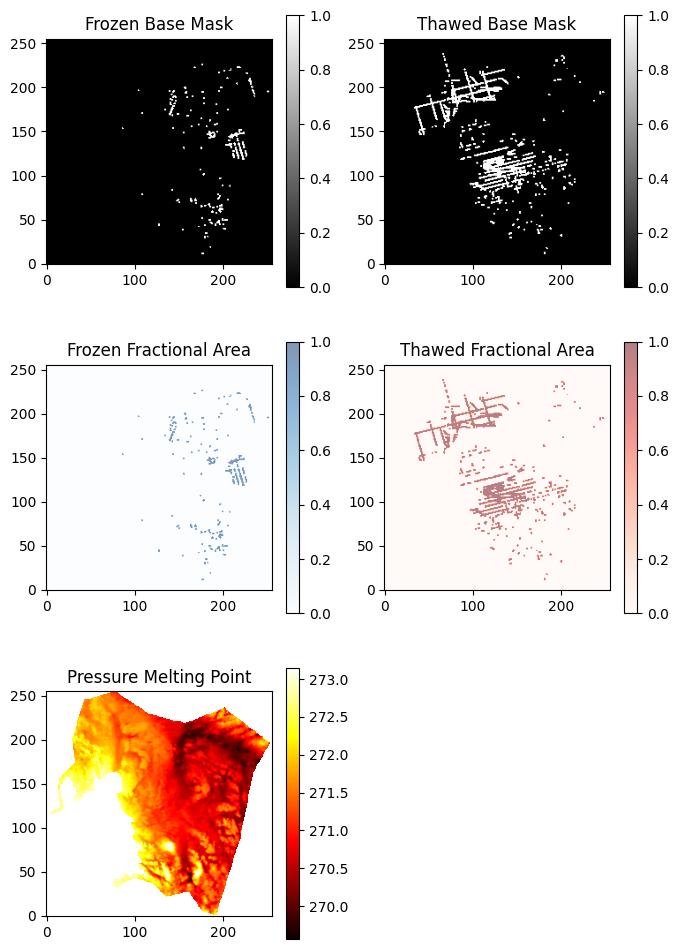

In [14]:
md.load_evidence(thawed_mask_data, thawed_fractional_area,
                 frozen_mask_data, frozen_fractional_area,
                 pmp,
                 show_plot=True)

#### Prior inflation

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from src.utilities import reverse_standardize
from src.ice import enthalpy_to_temperature
from tqdm.auto import tqdm
from gmr import GMM

# ── Configuration ─────────────────────────────────────────────────────────────
N_SAMPLES_BISECT = 500
N_SAMPLES_FINAL  = 2000
P_THAWED         = 95
P_FROZEN         = 5
ERR_EPS          = 1.0
BISECT_TOL       = 1e-3
BISECT_MAX_ITER  = 30
S_MAX            = 10.0
CONSISTENCY_TARGET = 0.90   # accept 90% rather than demanding 100% 
                             # (last 10% is likely mean-biased, unfixable by variance)


# ── Build perturbed GMM ───────────────────────────────────────────────────────
def build_perturbed_gmm(gmm_original, scale_vector):
    new_covs = gmm_original.covariances.copy()
    diag_idx = np.arange(len(scale_vector))
    new_covs[:, diag_idx, diag_idx] *= scale_vector ** 2
    return GMM(
        n_components = gmm_original.n_components,
        priors       = gmm_original.priors.copy(),
        means        = gmm_original.means.copy(),
        covariances  = new_covs,
        random_state = gmm_original.random_state
    )


# ── Batched Tb percentile computation ────────────────────────────────────────
def sample_tb_percentiles(gmm, md, n_samples=N_SAMPLES_FINAL, desc="Sampling"):
    samples  = gmm.sample(n_samples)
    Eb_batch = md.pca_x.inverse_transform(samples)     # vectorized PCA step
    domain_flat = md.domain_mask.flatten()
    Tb_all   = np.zeros((n_samples, int(domain_flat.sum())))

    for i in tqdm(range(n_samples), desc=desc, leave=False):
        Eb_ori = reverse_standardize(Eb_batch[i], md.X_mean, md.X_std,
                                     method='relaxation', epsilon=md.X_epsilon)
        Tb_ori = enthalpy_to_temperature(Eb_ori, md.pmp, istorch=False)
        Tb_all[i] = Tb_ori[domain_flat]

    return (np.nanpercentile(Tb_all, P_FROZEN,  axis=0),
            np.nanpercentile(Tb_all, P_THAWED, axis=0))


# ── Consistency scores ────────────────────────────────────────────────────────
def consistency_scores(Tb_plow, Tb_phigh, md, err_eps=ERR_EPS):
    flat_pmp   = md.pmp.flatten()
    full_shape = flat_pmp.shape[0]
    domain_idx = np.where(md.domain_mask.flatten())[0]

    Tb_phigh_full = np.full(full_shape, np.nan)
    Tb_plow_full  = np.full(full_shape, np.nan)
    Tb_phigh_full[domain_idx] = Tb_phigh
    Tb_plow_full[domain_idx]  = Tb_plow

    thawed_m = md.thawed_mask.flatten().astype(bool)
    frozen_m = md.frozen_mask.flatten().astype(bool)

    thawed_ok = (Tb_phigh_full[thawed_m] - flat_pmp[thawed_m]) >= -err_eps
    frozen_ok = (Tb_plow_full[frozen_m]  - flat_pmp[frozen_m]) <= -err_eps

    frac_thawed = np.mean(thawed_ok) if thawed_m.any() else 1.0
    frac_frozen = np.mean(frozen_ok) if frozen_m.any() else 1.0
    return frac_thawed, frac_frozen


# ── Phase 1: global bisection (all dims scaled equally) ──────────────────────
def find_global_scale(md, target=CONSISTENCY_TARGET, verbose=True):
    """
    Bisect a single global scalar s applied to ALL PCA dims simultaneously.
    This is a 1D bisection — cheap and handles the joint coverage problem.
    Returns s_global.
    """
    print("── Phase 1: Global scale bisection ─────────────────────────────────")

    def evaluate(s_global):
        sv    = np.full(md.pca_x.n_components_, s_global)
        gmm_p = build_perturbed_gmm(md.gmm_prop, sv)
        Tb_pl, Tb_ph = sample_tb_percentiles(gmm_p, md,
                                              n_samples=N_SAMPLES_BISECT,
                                              desc=f"  s={s_global:.4f}")
        ft, ff = consistency_scores(Tb_pl, Tb_ph, md)
        return ft, ff

    # Quick check: is S_MAX even sufficient?
    ft_max, ff_max = evaluate(S_MAX)
    print(f"  s={S_MAX:.1f} → Thawed: {ft_max:.3f}  Frozen: {ff_max:.3f}")
    if ft_max < target:
        print(f"  ⚠ WARNING: even S_MAX={S_MAX} cannot reach target={target:.2f}.")
        print(f"    The remaining {1-ft_max:.1%} thawed deficit is likely mean-biased.")
        print(f"    Returning S_MAX as best achievable global scale.")
        return S_MAX, ft_max, ff_max

    # Bisect
    s_lo, s_hi = 1.0, S_MAX
    s_best     = S_MAX
    ft_best, ff_best = ft_max, ff_max

    bisect_bar = tqdm(range(BISECT_MAX_ITER), desc="Global bisect", unit="iter")
    for _ in bisect_bar:
        s_mid    = 0.5 * (s_lo + s_hi)
        ft, ff   = evaluate(s_mid)
        thawed_ok = ft >= target
        frozen_ok = ff >= target

        bisect_bar.set_postfix({
            "s":      f"{s_mid:.4f}",
            "thawed": f"{ft:.3f}",
            "frozen": f"{ff:.3f}",
            "ok":     "✓" if (thawed_ok and frozen_ok) else "✗"
        })

        if thawed_ok and frozen_ok:
            s_best, ft_best, ff_best = s_mid, ft, ff
            s_hi = s_mid
        else:
            s_lo = s_mid

        if (s_hi - s_lo) < BISECT_TOL:
            break

    print(f"\n  Global scale found: s* = {s_best:.4f}  "
          f"(Thawed: {ft_best:.3f}  Frozen: {ff_best:.3f})")
    return s_best, ft_best, ff_best


# ── Phase 2: per-dim refinement from global scale ────────────────────────────
def refine_per_dim(md, s_global, verbose=True):
    """
    Starting from s_global on all dims, try to reduce each dim's scale
    back toward 1.0 (LASSO minimization) while maintaining consistency.
    This is now tractable because we start from a feasible point.
    """
    print("\n── Phase 2: Per-dim refinement (LASSO minimization) ─────────────────")
    n_dims       = md.pca_x.n_components_
    scale_vector = np.full(n_dims, s_global)

    dim_bar = tqdm(range(n_dims), desc="Refining dims", unit="dim")
    for k in dim_bar:

        # Try reducing dim k toward 1.0 via bisection
        s_lo, s_hi = 1.0, scale_vector[k]
        s_best     = scale_vector[k]   # fallback: keep global scale

        for _ in range(BISECT_MAX_ITER):
            s_mid = 0.5 * (s_lo + s_hi)
            sv    = scale_vector.copy()
            sv[k] = s_mid
            gmm_p = build_perturbed_gmm(md.gmm_prop, sv)
            Tb_pl, Tb_ph = sample_tb_percentiles(gmm_p, md,
                                                  n_samples=N_SAMPLES_BISECT,
                                                  desc=f"  dim {k} s={s_mid:.3f}")
            ft, ff = consistency_scores(Tb_pl, Tb_ph, md)

            if ft >= CONSISTENCY_TARGET and ff >= CONSISTENCY_TARGET:
                s_best = s_mid   # still consistent → reduce further
                s_hi   = s_mid
            else:
                s_lo   = s_mid   # inconsistent → need more variance

            if (s_hi - s_lo) < BISECT_TOL:
                break

        reduction = scale_vector[k] - s_best
        scale_vector[k] = s_best
        dim_bar.set_postfix({
            "dim":       k,
            "scale":     f"{s_best:.4f}",
            "reduced_by":f"{reduction:.4f}"
        })
        if verbose:
            print(f"  Dim {k:3d}: {s_global:.4f} → {s_best:.4f}  "
                  f"(reduced by {reduction:.4f})")

    return scale_vector


# ── Main ──────────────────────────────────────────────────────────────────────
def inflate_gmm_covariance(md, refine=True, verbose=True):
    """
    Phase 1 : 1D global bisection  — finds minimal uniform scale s* across
              all PCA dims that achieves CONSISTENCY_TARGET.
    Phase 2 : Per-dim refinement   — starting from s*, tries to reduce each
              dim back toward 1 while keeping consistency (LASSO spirit).
    Phase 3 : Final full evaluation at N=2000.

    Parameters
    ----------
    refine : bool
        If True, run Phase 2 refinement. If False, return uniform s* directly.
        Set False for a quick result; True for a more parsimonious solution.
    """
    n_dims = md.pca_x.n_components_

    # ── Baseline ──────────────────────────────────────────────────────────────
    print("── Phase 0: Baseline ────────────────────────────────────────────────")
    gmm0 = build_perturbed_gmm(md.gmm_prop, np.ones(n_dims))
    Tb_pl0, Tb_ph0 = sample_tb_percentiles(gmm0, md,
                                            n_samples=N_SAMPLES_BISECT,
                                            desc="Baseline")
    ft0, ff0 = consistency_scores(Tb_pl0, Tb_ph0, md)
    print(f"Baseline — Thawed: {ft0:.3f}  Frozen: {ff0:.3f}\n")

    # ── Phase 1 ───────────────────────────────────────────────────────────────
    s_global, ft_g, ff_g = find_global_scale(md, verbose=verbose)

    # ── Phase 2 (optional) ────────────────────────────────────────────────────
    if refine:
        scale_vector = refine_per_dim(md, s_global, verbose=verbose)
    else:
        scale_vector = np.full(n_dims, s_global)
        print(f"\nSkipping refinement — uniform scale s*={s_global:.4f} on all dims.")

    # ── Phase 3: final evaluation ─────────────────────────────────────────────
    print(f"\n── Phase 3: Final evaluation (N={N_SAMPLES_FINAL}) ──────────────────────────")
    gmm_inflated = build_perturbed_gmm(md.gmm_prop, scale_vector)
    Tb_pl_f, Tb_ph_f = sample_tb_percentiles(gmm_inflated, md,
                                              n_samples=N_SAMPLES_FINAL,
                                              desc="Final eval")
    ft_f, ff_f = consistency_scores(Tb_pl_f, Tb_ph_f, md)
    lasso      = np.sum((scale_vector - 1.0) ** 2)
    n_inflated = np.sum(scale_vector > 1.0 + BISECT_TOL)

    print(f"Final — Thawed: {ft_f:.3f}  Frozen: {ff_f:.3f}")
    print(f"LASSO penalty Σ(s−1)²    : {lasso:.4f}")
    print(f"Dims inflated (s > 1.001): {n_inflated} / {n_dims}")

    history = [dict(dim=k, scale=scale_vector[k]) for k in range(n_dims)]
    return gmm_inflated, scale_vector, history


# ── Run — set refine=False for speed, True for parsimony ─────────────────────
gmm_inflated, scale_vector, history = inflate_gmm_covariance(
    md, refine=False, verbose=True   # flip to True once global scale looks good
)


── Phase 0: Baseline ────────────────────────────────────────────────


Baseline — Thawed: 0.271  Frozen: 0.999

── Phase 1: Global scale bisection ─────────────────────────────────


  s=10.0 → Thawed: 0.982  Frozen: 1.000


Global bisect:  43%|████▎     | 13/30 [00:28<00:37,  2.22s/iter, s=5.2160, thawed=0.902, frozen=1.000, ok=✓]



  Global scale found: s* = 5.2160  (Thawed: 0.902  Frozen: 1.000)

Skipping refinement — uniform scale s*=5.2160 on all dims.

── Phase 3: Final evaluation (N=2000) ──────────────────────────


Final — Thawed: 0.894  Frozen: 1.000
LASSO penalty Σ(s−1)²    : 888.7342
Dims inflated (s > 1.001): 50 / 50


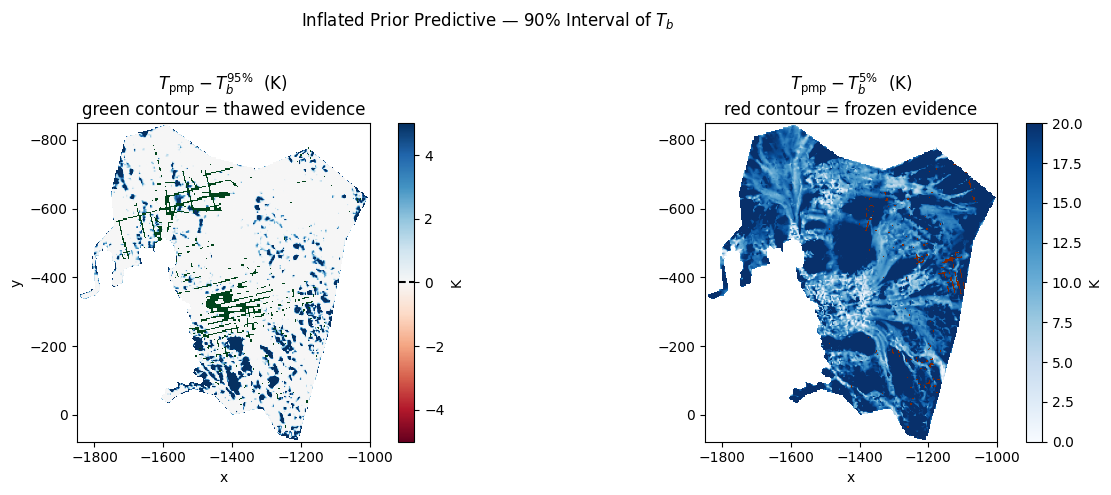

Thawed pixels — 95th pct of Tb relative to pmp:
  mean  : -0.44 K
  median: +0.00 K
  min   : -18.79 K   ← worst uncovered pixel

Frozen pixels — 5th pct of Tb relative to pmp:
  mean  : -20.82 K
  median: -19.18 K
  max   : -3.38 K   ← closest to melting


In [ ]:
# ── Compute Tb percentiles from inflated GMM at full resolution ───────────────
Tb_plow_inf, Tb_phigh_inf = sample_tb_percentiles(
    gmm_inflated, md, n_samples=N_SAMPLES_FINAL, desc="Percentile maps"
)

# ── Reconstruct spatial maps ──────────────────────────────────────────────────
domain_idx = np.where(md.domain_mask.flatten())[0]
full_shape = md.domain_mask.flatten().shape[0]
grid_shape = (md.ny, md.nx)
flat_pmp   = md.pmp.flatten()

def to_map(arr_domain, full_shape, domain_idx, grid_shape):
    m = np.full(full_shape, np.nan)
    m[domain_idx] = arr_domain
    return m.reshape(grid_shape)

pmp_map      = flat_pmp.reshape(grid_shape)
Tb_phigh_map = to_map(Tb_phigh_inf, full_shape, domain_idx, grid_shape)
Tb_plow_map  = to_map(Tb_plow_inf,  full_shape, domain_idx, grid_shape)

# pmp - Tb: positive means below melting point (frozen-ish)
#           near zero / negative means at or above melting point (thawed)
delta_high = pmp_map - Tb_phigh_map   # 95th pct: how close the warm tail gets to pmp
delta_low  = pmp_map - Tb_plow_map    # 5th  pct: how far the cold tail is from pmp

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: pmp - T_b at 95th percentile
# Values near 0 or negative → warm tail reaches/exceeds melting point (thawed-consistent)
# Large positive → even warm tail is well below melting point
im0 = axes[0].imshow(
    delta_high,
    extent=md.extent, origin='lower',
    cmap='RdBu',
    vmin=-5, vmax=5
)
axes[0].set_title(r"$T_\mathrm{pmp} - T_b^{95\%}$  (K)"
                  "\n(negative = warm tail exceeds melting point)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
cb0 = fig.colorbar(im0, ax=axes[0], label="K")
cb0.ax.axhline(0, color='k', lw=1.5, linestyle='--')   # zero line = at melting point

# Overlay thawed evidence locations
thawed_map = md.thawed_mask.reshape(grid_shape).astype(float)
thawed_map[thawed_map == 0] = np.nan
axes[0].imshow(thawed_map,
                extent=md.extent, origin='lower',
                cmap='Greens',
                vmin=0, vmax=1)
axes[0].set_title(r"$T_\mathrm{pmp} - T_b^{95\%}$  (K)"
                  "\ngreen = thawed evidence")

# Right: pmp - T_b at 5th percentile
# Large positive → cold tail is well below melting point (frozen-consistent)
im1 = axes[1].imshow(
    delta_low,
    extent=md.extent, origin='lower',
    cmap='Blues',
    vmin=0, vmax=20
)
axes[1].set_title(r"$T_\mathrm{pmp} - T_b^{5\%}$  (K)"
                  "\n(large = cold tail well below melting point)")
axes[1].set_xlabel("x")
cb1 = fig.colorbar(im1, ax=axes[1], label="K")

# Overlay frozen evidence locations
frozen_map = md.frozen_mask.reshape(grid_shape).astype(float)
frozen_map[frozen_map == 0] = np.nan
axes[1].imshow(frozen_map,
                extent=md.extent, origin='lower',
                cmap='Oranges',
                vmin=0, vmax=1)
axes[1].set_title(r"$T_\mathrm{pmp} - T_b^{5\%}$  (K)"
                  "\norange = frozen evidence")

plt.suptitle("Inflated Prior Predictive — 90% Interval of $T_b$\n",
             fontsize=12)
plt.tight_layout()
plt.show()

# ── Quick pixel-level consistency summary ─────────────────────────────────────
thawed_m = md.thawed_mask.flatten().astype(bool)
frozen_m = md.frozen_mask.flatten().astype(bool)

Tb_phigh_full = np.full(full_shape, np.nan)
Tb_plow_full  = np.full(full_shape, np.nan)
Tb_phigh_full[domain_idx] = Tb_phigh_inf
Tb_plow_full[domain_idx]  = Tb_plow_inf

thawed_delta = Tb_phigh_full[thawed_m] - flat_pmp[thawed_m]
frozen_delta = Tb_plow_full[frozen_m]  - flat_pmp[frozen_m]

print("Thawed pixels — 95th pct of Tb relative to pmp:")
print(f"  mean  : {np.nanmean(thawed_delta):+.2f} K")
print(f"  median: {np.nanmedian(thawed_delta):+.2f} K")
print(f"  min   : {np.nanmin(thawed_delta):+.2f} K   ← worst uncovered pixel")

print("\nFrozen pixels — 5th pct of Tb relative to pmp:")
print(f"  mean  : {np.nanmean(frozen_delta):+.2f} K")
print(f"  median: {np.nanmedian(frozen_delta):+.2f} K")
print(f"  max   : {np.nanmax(frozen_delta):+.2f} K   ← closest to melting")


Sampling from original GMM...


Sampling from inflated GMM...


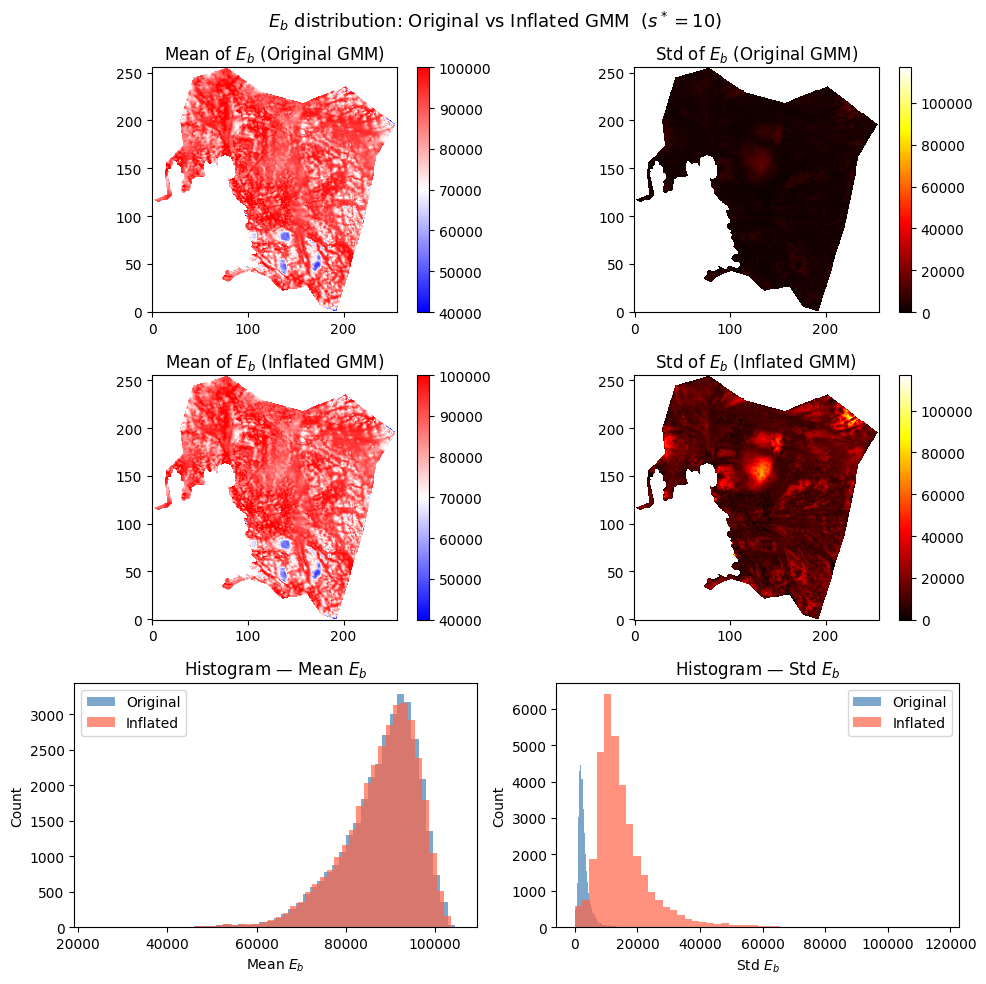

In [44]:
# ── Generate enthalpy samples from both GMMs ──────────────────────────────────
N_PLOT_SAMPLES = 500   # enough for stable mean/std maps, fast to compute

def gmm_to_enthalpy_samples(gmm, md, n_samples=N_PLOT_SAMPLES):
    """
    Draw n_samples from gmm, push through PCA inverse + reverse_standardize.
    Returns Eb_ori of shape (n_grid_flat, n_samples) to match existing code convention.
    """
    samples  = gmm.sample(n_samples)                        # (n_samples, n_pca)
    Eb_batch = md.pca_x.inverse_transform(samples)          # (n_samples, n_grid_flat)

    Eb_ori_all = np.zeros_like(Eb_batch)
    for i in tqdm(range(n_samples), desc="Eb samples", leave=False):
        Eb_ori_all[i] = reverse_standardize(Eb_batch[i], md.X_mean, md.X_std,
                                             method='relaxation',
                                             epsilon=md.X_epsilon)

    return Eb_ori_all.T    # → (n_grid_flat, n_samples)  matches existing convention


print("Sampling from original GMM...")
Eb_orig_samples = gmm_to_enthalpy_samples(
    build_perturbed_gmm(md.gmm_prop, np.ones(md.pca_x.n_components_)), md
)

print("Sampling from inflated GMM...")
Eb_infl_samples = gmm_to_enthalpy_samples(gmm_inflated, md)


# ── Compute mean / std maps ───────────────────────────────────────────────────
def make_mean_std_maps(Eb_samples, md):
    """Returns (mean_map, std_map) each shape (nx, ny) with NaN outside domain."""
    mean_map = np.mean(Eb_samples, axis=1).reshape(md.nx, md.ny)
    std_map  = np.std( Eb_samples, axis=1).reshape(md.nx, md.ny)
    mean_map[md.domain_mask == False] = np.nan
    std_map[ md.domain_mask == False] = np.nan
    return mean_map, std_map

mean_orig, std_orig = make_mean_std_maps(Eb_orig_samples, md)
mean_infl, std_infl = make_mean_std_maps(Eb_infl_samples, md)


# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(10, 10))

# shared color limits
vmax_std  = max(np.nanmax(std_orig),  np.nanmax(std_infl))
vmax_mean = max(np.nanmax(np.abs(mean_orig)), np.nanmax(np.abs(mean_infl)))

# ── Row 1: original GMM ───────────────────────────────────────────────────────
im0 = axes[0, 0].imshow(mean_orig, cmap='bwr',
                         vmin=40000, vmax=100000)
axes[0, 0].set_title(r'Mean of $E_b$ (Original GMM)')
axes[0, 0].invert_yaxis()
fig.colorbar(im0, ax=axes[0, 0])

im1 = axes[0, 1].imshow(std_orig, cmap='hot',
                         vmin=0, vmax=vmax_std)
axes[0, 1].set_title(r'Std of $E_b$ (Original GMM)')
axes[0, 1].invert_yaxis()
fig.colorbar(im1, ax=axes[0, 1])

# ── Row 2: inflated GMM ───────────────────────────────────────────────────────
im2 = axes[1, 0].imshow(mean_infl, cmap='bwr',
                         vmin=40000, vmax=100000)
axes[1, 0].set_title(r'Mean of $E_b$ (Inflated GMM)')
axes[1, 0].invert_yaxis()
fig.colorbar(im2, ax=axes[1, 0])

im3 = axes[1, 1].imshow(std_infl, cmap='hot',
                         vmin=0, vmax=vmax_std)
axes[1, 1].set_title(r'Std of $E_b$ (Inflated GMM)')
axes[1, 1].invert_yaxis()
fig.colorbar(im3, ax=axes[1, 1])

# ── Row 3: histograms ─────────────────────────────────────────────────────────
domain_m = md.domain_mask.astype(bool)

axes[2, 0].hist(mean_orig[domain_m].flatten(), bins=50,
                color='steelblue', alpha=0.7, label='Original')
axes[2, 0].hist(mean_infl[domain_m].flatten(), bins=50,
                color='tomato',    alpha=0.7, label='Inflated')
axes[2, 0].set_xlabel(r'Mean $E_b$')
axes[2, 0].set_ylabel('Count')
axes[2, 0].set_title(r'Histogram — Mean $E_b$')
axes[2, 0].legend()

axes[2, 1].hist(std_orig[domain_m].flatten(), bins=50,
                color='steelblue', alpha=0.7, label='Original')
axes[2, 1].hist(std_infl[domain_m].flatten(), bins=50,
                color='tomato',    alpha=0.7, label='Inflated')
axes[2, 1].set_xlabel(r'Std $E_b$')
axes[2, 1].set_ylabel('Count')
axes[2, 1].set_title(r'Histogram — Std $E_b$')
axes[2, 1].legend()

plt.suptitle(r"$E_b$ distribution: Original vs Inflated GMM  ($s^* = 10$)",
             fontsize=13)
plt.tight_layout()
plt.show()


#### Prior predictive check (necessary to build an evidence mask)

Number of frozen grid points: 900
Number of thawed grid points: 3693
Sample 0/2000
Sample 500/2000
Sample 1000/2000
Sample 1500/2000


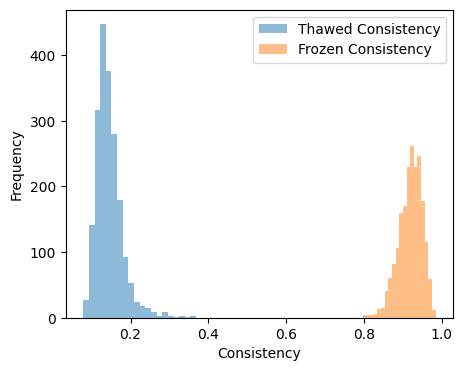

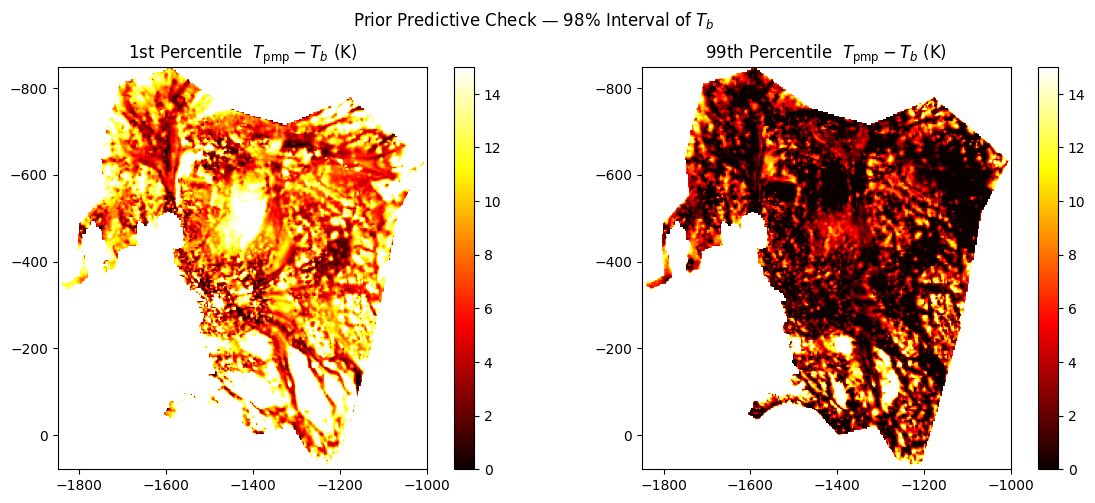

In [9]:
from src.utilities import reverse_standardize
from src.ice import enthalpy_to_temperature
# sample from prior and compute the likelihood
n_prior_samples = 2000
prior_samples = md.gmm_prop.sample(n_prior_samples)

n_frozen = np.sum(md.frozen_mask)
n_thawed = np.sum(md.thawed_mask)
print("Number of frozen grid points:", n_frozen)
print("Number of thawed grid points:", n_thawed)

thawed_consistent = np.zeros(n_prior_samples,)
frozen_consistent = np.zeros(n_prior_samples,)
Tb_prior_samples = np.zeros((n_prior_samples, md.domain_mask.sum()))  
for i, sample in enumerate(prior_samples):
    Eb_sample = md.pca_x.inverse_transform(sample)
    Eb_sample_ori = reverse_standardize(Eb_sample,
                                        md.X_mean, 
                                        md.X_std, 
                                        method='relaxation',
                                        epsilon=md.X_epsilon)
    Tb_sample_ori = enthalpy_to_temperature(Eb_sample_ori, md.pmp, istorch=False)
    Tb_prior_samples[i] = Tb_sample_ori[md.domain_mask.flatten()]

    thawed = (Tb_sample_ori - md.pmp) >= -1
    frozen = (md.pmp - Tb_sample_ori) >= 1

    thawed[md.domain_mask.flatten() == False] = np.nan
    frozen[md.domain_mask.flatten() == False] = np.nan

    frozen_consistent[i] = np.nansum(frozen[md.frozen_mask==True])
    thawed_consistent[i] = np.nansum(thawed[md.thawed_mask==True])

    if i % 500 == 0:
        print("Sample {}/{}".format(i, n_prior_samples))

plt.figure(figsize=(5,4))
plt.hist(thawed_consistent/n_thawed, bins=20, alpha=0.5, label='Thawed Consistency')
plt.hist(frozen_consistent/n_frozen, bins=20, alpha=0.5, label='Frozen Consistency')
plt.xlabel('Consistency')
plt.ylabel('Frequency')
plt.legend()
plt.show()


# Compute percentiles across samples (axis=0 → per pixel)
Tb_plow = np.nanpercentile(Tb_prior_samples, 1,  axis=0)
Tb_phigh = np.nanpercentile(Tb_prior_samples, 99, axis=0)

# Reconstruct spatial maps
domain_idx = np.where(md.domain_mask.flatten())[0]
Tb_plow_map = np.full(md.domain_mask.flatten().shape, np.nan)
Tb_phigh_map = np.full(md.domain_mask.flatten().shape, np.nan)
Tb_plow_map[domain_idx] = Tb_plow
Tb_phigh_map[domain_idx] = Tb_phigh

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(md.pmp.reshape(md.ny, md.nx) - Tb_plow_map.reshape(md.ny, md.nx),
                      extent=md.extent, origin='lower', cmap='hot',
                      vmin=0, vmax=15)
axes[0].set_title("1st Percentile  $T_\\mathrm{pmp} - T_b$ (K)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(md.pmp.reshape(md.ny, md.nx) - Tb_phigh_map.reshape(md.ny, md.nx),
                      extent=md.extent, origin='lower', cmap='hot',
                      vmin=0, vmax=15)
axes[1].set_title("99th Percentile  $T_\\mathrm{pmp} - T_b$ (K)")
plt.colorbar(im1, ax=axes[1])

plt.suptitle("Prior Predictive Check — 98% Interval of $T_b$")
plt.tight_layout()
plt.show()

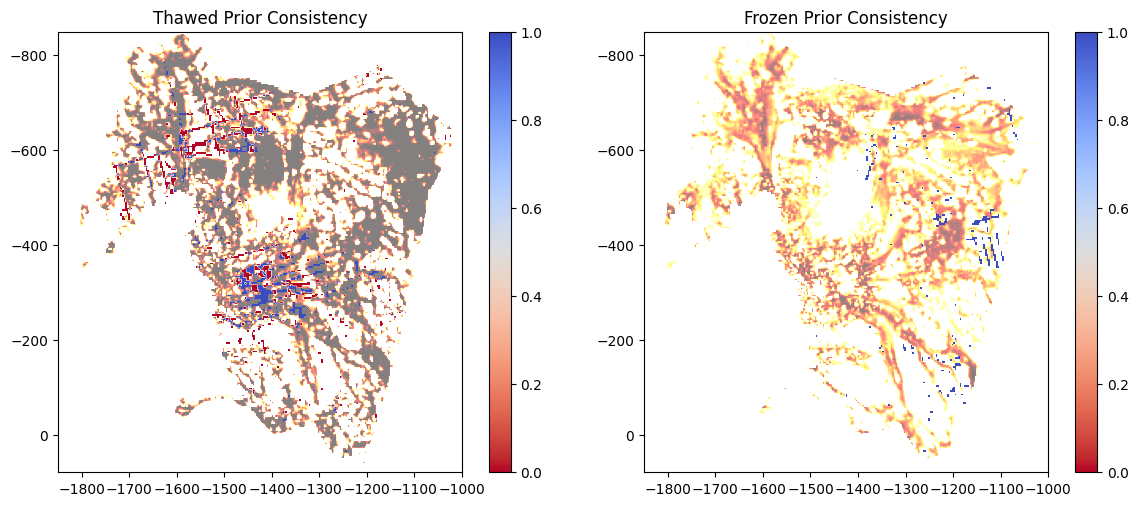

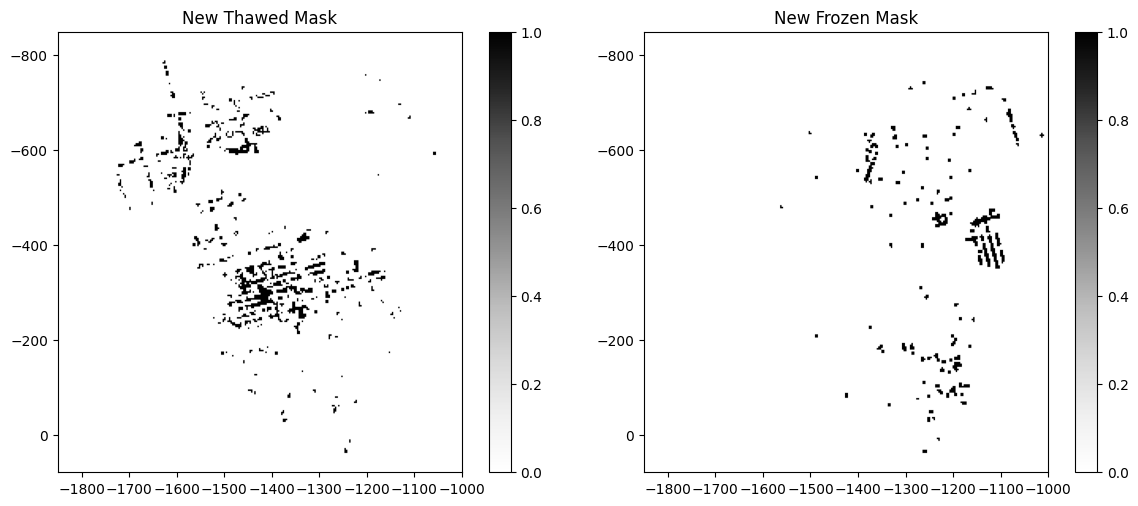

In [10]:
# ── Basal Evidence Consistency Check ─────────────────────────────────────────
# Thawed: 99th percentile of Tb must be below pmp - err_eps  (i.e. Tb_high < pmp - ε)
# Frozen:  1st percentile of Tb must be above pmp + err_eps  (i.e. Tb_low  > pmp + ε)

err_eps = 1

flat_shape  = md.thawed_mask.size  
thawed_mask = md.thawed_mask.flatten().astype(bool)
frozen_mask = md.frozen_mask.flatten().astype(bool)

# ── Percentile deltas relative to pressure-melting point ─────────────────────
thawed_delta = np.full(flat_shape, np.nan)
frozen_delta = np.full(flat_shape, np.nan)

thawed_delta[thawed_mask] = Tb_phigh_map.flatten()[thawed_mask] - md.pmp.flatten()[thawed_mask]
frozen_delta[frozen_mask] = Tb_plow_map.flatten()[frozen_mask]  - md.pmp.flatten()[frozen_mask]

# ── Consistency flags ─────────────────────────────────────────────────────────
thawed_consistent = np.where(thawed_mask, thawed_delta > -err_eps, np.nan)
frozen_consistent = np.where(frozen_mask,  frozen_delta  < -err_eps, np.nan)

# ── Plot ──────────────────────────────────────────────────────────────────────
grid_shape = (md.ny, md.nx)
vlims = [(0, 3), (0, 10)]
plot_pairs = [
    (md.pmp.reshape(md.ny, md.nx) - Tb_phigh_map.reshape(md.ny, md.nx), thawed_consistent, "Thawed Prior Consistency", vlims[0]),
    (md.pmp.reshape(md.ny, md.nx) - Tb_plow_map.reshape(md.ny, md.nx), frozen_consistent,  "Frozen Prior Consistency", vlims[1]),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (bg, data, title, vlim) in zip(axes, plot_pairs):
    imbg = ax.imshow(bg.reshape(grid_shape), extent=md.extent,
                     origin='lower', cmap='hot',
                     vmin=vlim[0], vmax=vlim[1],
                     alpha=0.5, zorder=1)
    im = ax.imshow(data.reshape(grid_shape), extent=md.extent,
                   origin='lower', cmap='coolwarm_r',
                   vmin=0, vmax=1,
                   alpha=1, zorder=2)
    ax.set_title(title)
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# subselect the valid thawed and frozen evidence based on this prior check
new_thawed_mask = np.where(thawed_consistent == 1, True, False)
new_frozen_mask = np.where(frozen_consistent == 1, True, False)
# convert to 0 and 1
new_thawed_mask = new_thawed_mask.astype(int)
new_frozen_mask = new_frozen_mask.astype(int)
# make new plots for visual inspection
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.imshow(new_thawed_mask.reshape(grid_shape), extent=md.extent, origin='lower', cmap='Greys',
           vmin=0, vmax=1)
plt.title("New Thawed Mask")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(new_frozen_mask.reshape(grid_shape), extent=md.extent, origin='lower', cmap='Greys',
           vmin=0, vmax=1)
plt.title("New Frozen Mask")
plt.colorbar()

plt.tight_layout()
plt.show()

# do the same for fractional area
new_thawed_fractional_area = np.where(thawed_consistent == 1, thawed_fractional_area, 0)
new_frozen_fractional_area = np.where(frozen_consistent == 1, frozen_fractional_area, 0)

# Part (VI): Sampling the posterior

we seek to search the Maximum a Posteriori (MAP) in the latent space. We continue to denote variables in the latent space with asterisk. We denote known basal evidence as $\omega$. Assuming that each evidence across the drainage basin is independent:
\begin{align}
    P(\omega|E_b^*) = \Pi_{i=1}^N \left[e^{-\frac{1}{\beta}\left(T_{pmp}^i-\mathcal{F}(E_b^{*,i})\right)}\right]^{\delta_t^i}\Pi_{k=1}^M \left[1+(\epsilon-1)e^{-\frac{1}{\beta}\left(T_\text{pmp}^k-\mathcal{F}(E_b^{*,k})\right)} \right]^{\delta_f^k}
\end{align}
where function $\mathcal{F}(E_b^*)$ converts the basal enthalpy from the latent space to basal temperature in the physical space
\begin{equation}
    T_b = \mathcal{F}(E_b^*) = 
    \begin{cases}
        T_{\text{pmp}} & \text{if } V E_b^* (E_{b,\text{std}} + \hat{\epsilon}) + E_{b,\text{avg}} > C_p(T_{\text{pmp}} - T_0) \\[8pt]
        \frac{V E_b^* (E_{b,\text{std}} +\hat{\epsilon}) + E_{b,\text{avg}}}{C_p} + T_0 & \text{otherwise}
    \end{cases}
\end{equation}
and $E_{b,\text{std}},\, E_{b,\text{avg}}$ are the across-sample mean, standard deviation used in the pre-processing standardization; $\hat{\epsilon}$ is a small number ($5\%$ quantile of standard deviation) in the standardization to avoid zero division; $C_p$ is heat capacity of ice, $T_0$ is reference temperature at 223.15 K, and $T_\text{pmp}$ is pressure melting point. $N$ is the total number of observed subglacial water in the domain (i.e. number of pixels), $M$ is the total number of observed frozen base, $\delta_w$ and $\delta_f$ are fractional areas of water and frozen base, and are defined as $\delta_t=\frac{\sigma_t}{D}$ and $\delta_f = \frac{\sigma_f}{D}$ where $\sigma_t$ and $\sigma_f$ are areas of the evidence at each pixel and $D$ is the total drainage area. $\beta$ controls the e-folding temperature scale which is subject to tuning. The fractional areas $\delta_t, \delta_f$ are raised to exponents to ensure that the likelihood is invariant to the pixel resolution which influences $N$ and $M$. This can be seen in log probability space where the likelihood converges to their total areas:
\begin{align}
    \log P(\omega|E_b^*) & = -\frac{1}{\beta}\sum_i^N (T_\text{pmp}^i-\mathcal{F}(E_b^{*,i}))\delta_t^i + \sum_{k}^{M}  \log \left(1-e^{-\frac{1}{\beta}(T_\text{pmp}^k-\mathcal{F}(E_b^{*,k}))} \right)\delta_f^k \\
 & \approx -\frac{1}{D}\left[ \int_{\Omega_t} \frac{1}{\beta} (T_\text{pmp}- \mathcal{F}(E_b^*))\, d\sigma + \int_{\Omega_f}  \log \left(1-e^{-\frac{1}{\beta}(T_\text{pmp}-\mathcal{F}(E_b^*))} \right)\,d\sigma \right]
\end{align}
where the domain of thawed base and frozen base be denoted as $\Omega_w$ and $\Omega_f$.

In addition to the basal evidence, we also consider the physical constraint on basal enthalpy. In temperate ice, the water fraction is observed to be no more than $4\%$, and theoretical analysis confirms that water fraction exceeding xxx will cause .... Therefore we impose a maximum water fraction constraint on $E_b$
\begin{align}
    P(\psi|E^*_b) = \Pi_i^Q \left(\left[{1 + \exp\left[\frac{1}{\beta}\left(\mathcal{G}(E_b^{*,i}) - \hat{\phi}  \right)  \right]}\right]^{-1} + \epsilon\right)
\end{align}
where $\phi$ and $\hat{\phi}$ are water fraction and water fraction limit. The water fraction is computed as 
\begin{equation}
    \mathcal{G}(E_b^*) = \phi = 
    \begin{cases}
        0 & \text{if } V E_b^* (E_{b,\text{std}} + \hat{\epsilon}) + E_{b,\text{avg}} < C_p(T_{\text{pmp}} - T_0) \\[8pt]
        \frac{V E_b^* (E_{b,\text{std}} +\hat{\epsilon}) + E_{b,\text{avg}} - C_p(T_{pmp}-T_0)}{L} & \text{otherwise}
    \end{cases}
\end{equation}
and the limit $\hat{\phi}$ is set at 0.04.

Now we can define the optimization problem to find the MAP in the latent space. $z_\text{MAP}$ can be found via minimizing the negative log-posterior:
\begin{align}
    E_\text{b,MAP}^*  &= \arg \min \quad  -\left[\log P(\omega,\psi|E_b^*) + \log P(E_b^*) \right] \\
    & = \arg \min \quad \frac{1}{\beta}\sum_i^N (T_\text{pmp}^i-\mathcal{F}(E_b^{*,i}))\delta_t^i  \\ 
    & \quad \quad \quad \quad \quad - \sum_{k}^{M}  \log \left(1+(\epsilon-1)e^{-\frac{1}{\beta}(T_\text{pmp}^k-\mathcal{F}(E_b^{*,k}))} \right)\delta_f^k  \\
    & \quad \quad \quad \quad \quad - \sum_j^Q \log \left(\left[{1 + \exp\left[\frac{1}{\beta}\left(\mathcal{G}(E_b^{*,j}) - \hat{\phi}  \right)  \right]}\right]^{-1} + \epsilon\right) \\
    & \quad \quad \quad \quad \quad - \log P(E_b^*)
\end{align}


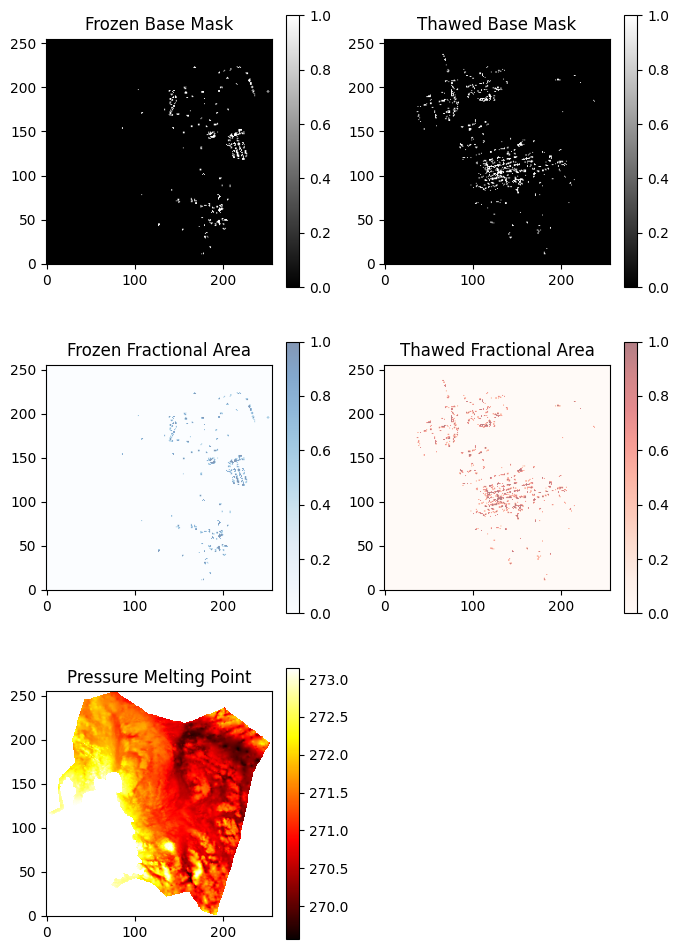

Starting iteration 1/10...
Iteration 1/10, Negative Log Posterior: 9781.1661
Starting iteration 2/10...


/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/notebooks/../src/amortization.py:442: RuntimeWarning: divide by zero encountered in log
  log_prob_components[:, k] = np.log(gmm.priors[k]) + log_norm + log_exponent
/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/notebooks/../src/optimization.py:278: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Eb_star_tensor = torch.tensor(Eb_star, requires_grad=True)
/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/notebooks/../src/optimization.py:131: RuntimeWarning: divide by zero encountered in log
  component_log_probs[k] = np.log(gmm.priors[k]) + np.log(norm_factor) + exponent[0]


Iteration 2/10, Negative Log Posterior: 8956.3786
Starting iteration 3/10...
Iteration 3/10, Negative Log Posterior: 8758.7184
Starting iteration 4/10...
Iteration 4/10, Negative Log Posterior: 8614.1142
Starting iteration 5/10...
Iteration 5/10, Negative Log Posterior: 8521.2413
Starting iteration 6/10...
Iteration 6/10, Negative Log Posterior: 8487.1145
Starting iteration 7/10...
Iteration 7/10, Negative Log Posterior: 8476.4619
Starting iteration 8/10...
Iteration 8/10, Negative Log Posterior: 8473.2547
Starting iteration 9/10...
Iteration 9/10, Negative Log Posterior: 8472.3778
Starting iteration 10/10...
Iteration 10/10, Negative Log Posterior: 8472.0826


/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/notebooks/../src/optimization.py:326: RuntimeWarning: divide by zero encountered in log
  component_log_probs[k] = (np.log(gmm.priors[k])


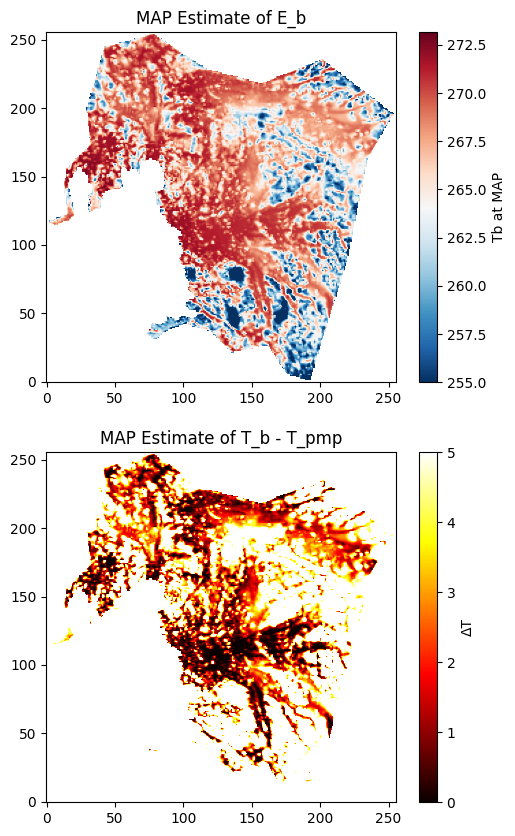

In [11]:
beta_posterior = 3 # taking the elbow point from the k-fold cross-validation analysis above
beta_w = 0.01 # water fraction
thinning_level = 0.3 # randomly remove 30% of the evidence to avoid overconstraining 

# thinning
new_thawed_mask_thinned = new_thawed_mask.copy()
new_frozen_mask_thinned = new_frozen_mask.copy()
new_thawed_fractional_area_thinned = new_thawed_fractional_area.copy()
new_frozen_fractional_area_thinned = new_frozen_fractional_area.copy()

thawed_indices = np.where(new_thawed_mask)[0]
frozen_indices = np.where(new_frozen_mask)[0]
num_thawed_to_remove = int(thinning_level * len(thawed_indices))
num_frozen_to_remove = int(thinning_level * len(frozen_indices))
thinned_thawed_indices = np.random.choice(thawed_indices, size=num_thawed_to_remove, replace=False)
thinned_frozen_indices = np.random.choice(frozen_indices, size=num_frozen_to_remove, replace=False)
new_thawed_mask_thinned[thinned_thawed_indices] = False
new_frozen_mask_thinned[thinned_frozen_indices] = False
new_thawed_fractional_area_thinned[thinned_thawed_indices] = 0
new_frozen_fractional_area_thinned[thinned_frozen_indices] = 0


md.load_evidence(new_thawed_mask_thinned, new_thawed_fractional_area_thinned,
                 new_frozen_mask_thinned, new_frozen_fractional_area_thinned,
                 pmp,
                 show_plot=True)

md.compute_MAP(beta=beta_posterior, beta_w=beta_w, n_iter=10, lr=0.1)

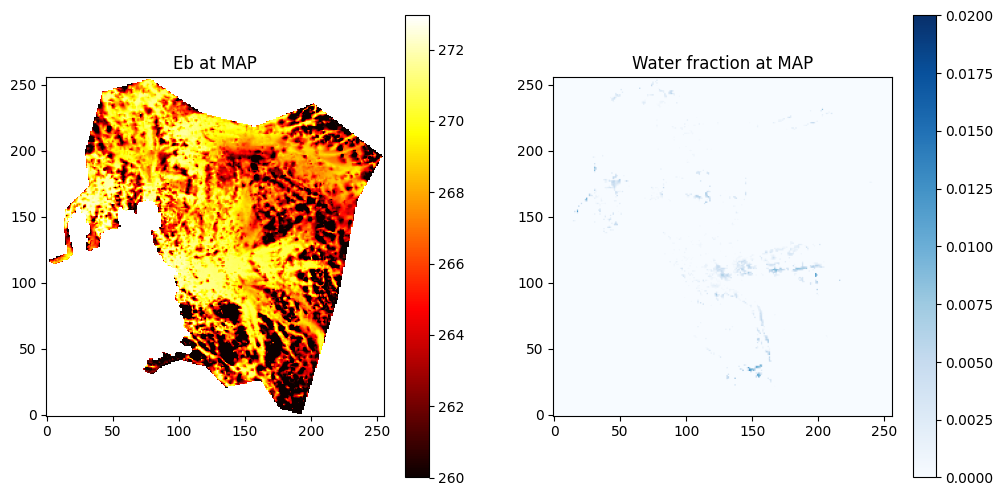

In [12]:
from src.ice import enthalpy_to_water_fraction
water_frac = enthalpy_to_water_fraction(md.Eb_MAP.flatten(), md.pmp, istorch=False)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(md.Tb_MAP, cmap='hot', vmin=260)
plt.gca().invert_yaxis()
plt.colorbar()
plt.title("Eb at MAP")
plt.subplot(1,2,2)
plt.imshow(water_frac.reshape(md.nx, md.ny), cmap='Blues', vmin=0, vmax=0.02)
plt.gca().invert_yaxis()
plt.colorbar()
plt.title("Water fraction at MAP")
plt.show()

Total consistent points: 1447 out of 1811 (79.90%)


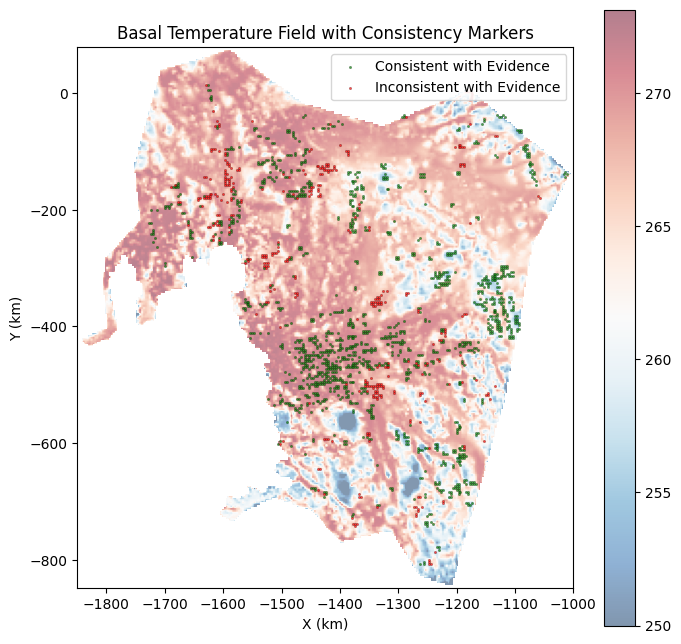

In [13]:
md.plot_evidence_consistency(md.Tb_MAP.flatten(), beta=beta_posterior)

In [14]:
md.explore_posterior(beta=beta_posterior, beta_w=beta_w, warmup_steps=1000, explore_samples=2000)


EXPLORE: Multi-chain exploratory run to discover modes
         chains=4, warmup=1000, samples=2000/chain (pool = 8000)

--- Explore chain 1 / 4 ---


Sample: 100%|██████████| 3000/3000 [17:37,  2.84it/s, step size=1.05e-01, acc. prob=0.804]


  Chain 1: collected 2000 samples, per-dim mean range [-47.559, 51.646]

--- Explore chain 2 / 4 ---


Sample: 100%|██████████| 3000/3000 [18:40,  2.68it/s, step size=7.86e-02, acc. prob=0.862]


  Chain 2: collected 2000 samples, per-dim mean range [-47.169, 51.269]

--- Explore chain 3 / 4 ---


...

  Chain 3: collected 2000 samples, per-dim mean range [-47.462, 51.387]

--- Explore chain 4 / 4 ---


Sample: 100%|██████████| 3000/3000 [20:17,  2.46it/s, step size=9.27e-02, acc. prob=0.827]


  Chain 4: collected 2000 samples, per-dim mean range [-47.268, 51.778]

Between-chain diagnostic (R-hat proxy): max = 1.002, mean = 1.000

Pooled exploratory samples: torch.Size([8000, 50])
  GMM K=1: BIC = 1767510.0
  GMM K=2: BIC = 1774526.0
  GMM K=3: BIC = 1783634.3
  GMM K=4: BIC = 1792983.5
  GMM K=5: BIC = 1802146.3
  GMM K=6: BIC = 1811457.8

Detected 1 mode(s) in full z-space (BIC-selected).


/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/notebooks/../src/amortization.py:442: RuntimeWarning: divide by zero encountered in log
  log_prob_components[:, k] = np.log(gmm.priors[k]) + log_norm + log_exponent


  Mode 1: occupancy = 1.000, 8000 samples, visited by chain(s) [1 2 3 4], init potential = 8481.4375

explore_posterior() complete. Call derive_posterior() to run full sampling.


In [15]:
hmc_md_name = posterior_path + "models/" + f"hmc_md_beta{beta_posterior}_betaw{beta_w}.pt"
md.derive_posterior(savename=hmc_md_name)


DERIVE: Full sampling from 1 mode(s)
        warmup=2000, samples=2000 per mode

--- Mode 1 / 1 ---


Warmup:   0%|          | 0/4000 [00:00, ?it/s]/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/notebooks/../src/optimization.py:278: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Eb_star_tensor = torch.tensor(Eb_star, requires_grad=True)
/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/notebooks/../src/optimization.py:131: RuntimeWarning: divide by zero encountered in log
  component_log_probs[k] = np.log(gmm.priors[k]) + np.log(norm_factor) + exponent[0]
Sample: 100%|██████████| 4000/4000 [20:15,  3.29it/s, step size=9.81e-02, acc. prob=0.819]


  Collected 2000 samples.

Mode weights (occupancy):
  Mode 1: 1.0000
  Mode 1: using 2000 samples (target weight 1.0000, realized 1.0000)

Total combined samples: 2000

Posterior samples saved to /data-archive/ASE-inference/posteriors/models/hmc_md_beta3_betaw0.01.pt


In [16]:
import torch.serialization

torch.serialization.add_safe_globals([
    np._core.multiarray._reconstruct,
    np.ndarray,
    np.dtype,
    np.dtypes.Float64DType,      # ← the new one causing this error
    np._core.multiarray.scalar,
])

hmc_sample_name = posterior_path + "samples/" + f"hmc_md_beta{beta_posterior}_betaw{beta_w}.pt"

low_percentile, high_percentile = 1, 99
md.analyze_posterior_samples(beta=beta_posterior, loading=True, 
                             loadname=hmc_md_name,
                             savename=hmc_sample_name,
                             quantile_range=(low_percentile, high_percentile))

Loaded samples from /data-archive/ASE-inference/posteriors/models/hmc_md_beta3_betaw0.01.pt
HMC Sampling Complete. Extracted shape: (2000, 50)
Sample: 2000/2000
Eb samples saved to /data-archive/ASE-inference/posteriors/samples/hmc_md_beta3_betaw0.01.pt and /data-archive/ASE-inference/posteriors/samples/hmc_md_beta3_betaw0.01.pt
Computing 1th and 99th percentiles for credible intervals...


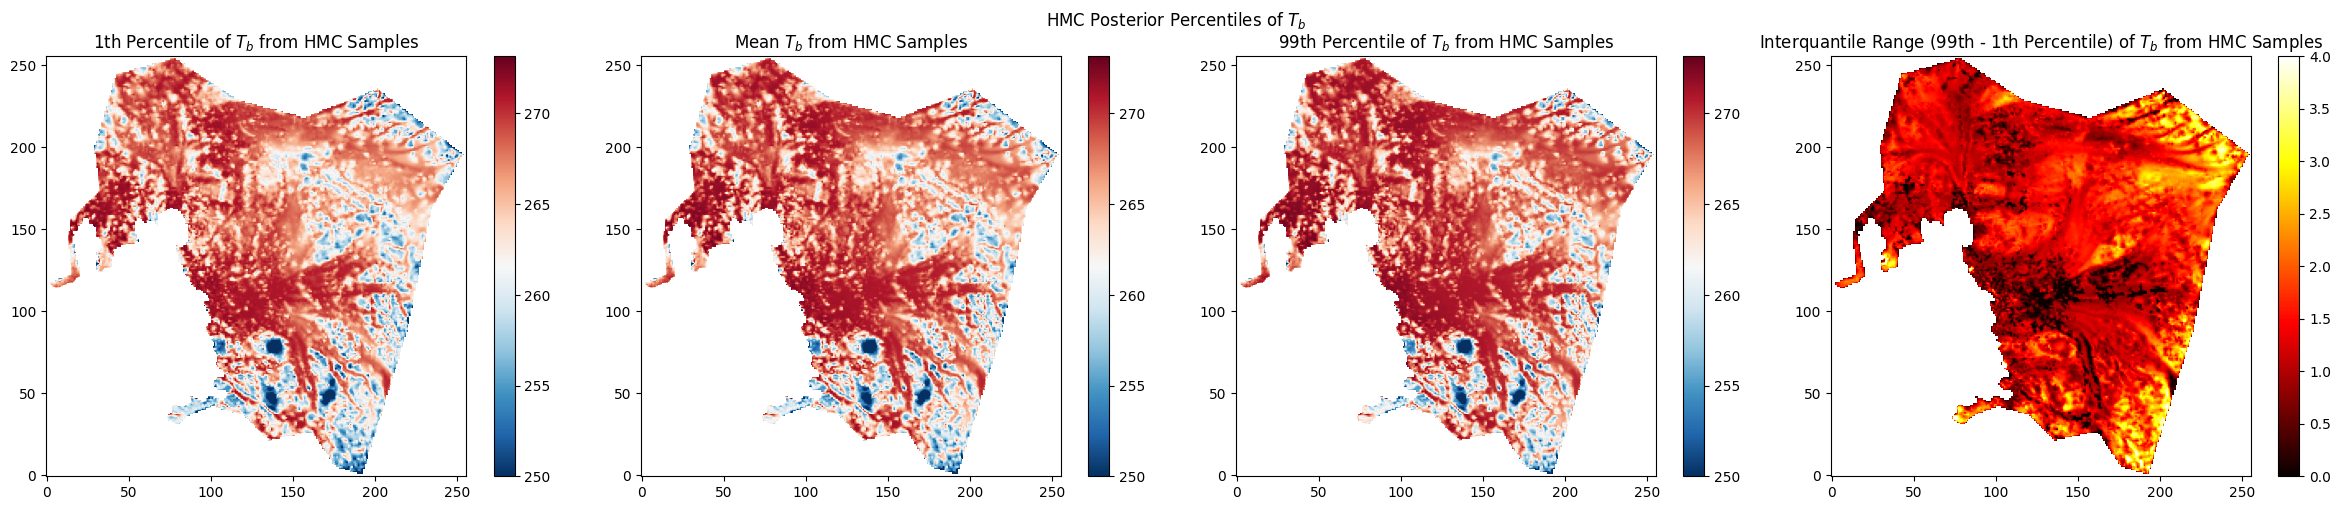

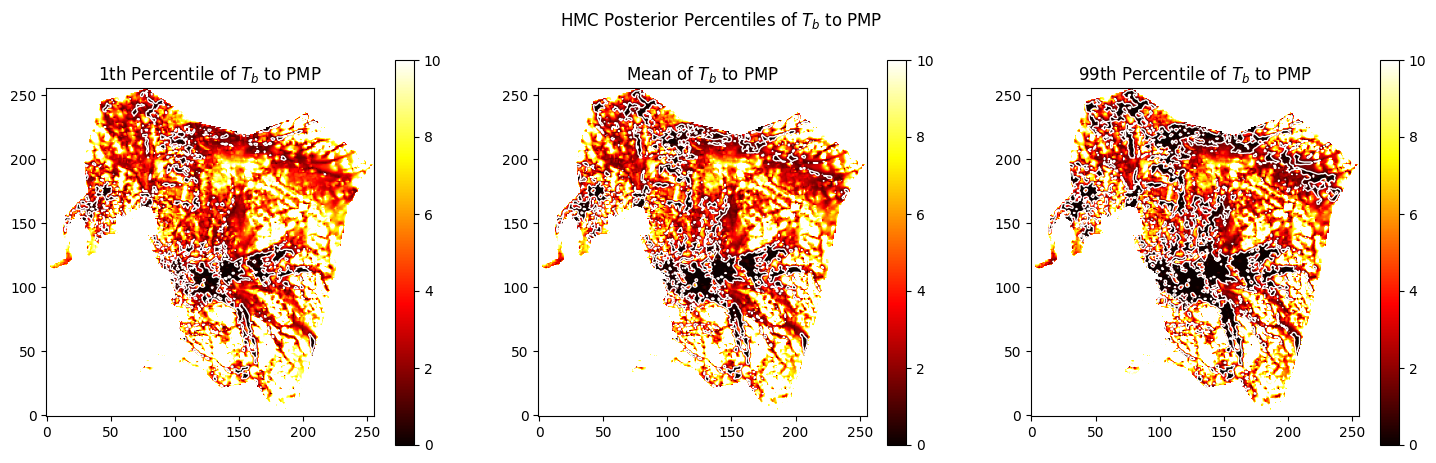

In [17]:
plt.figure(figsize=(24, 5))
plt.subplot(1, 4, 1)
plt.imshow(md.Tb_plow, cmap='RdBu_r', vmin=250, vmax=273.15)
plt.title(f'{low_percentile}th Percentile of $T_b$ from HMC Samples')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1, 4, 2)
plt.imshow(md.Tb_mean, cmap='RdBu_r', vmin=250, vmax=273.15)
plt.title('Mean $T_b$ from HMC Samples')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1, 4, 3)
plt.imshow(md.Tb_phigh, cmap='RdBu_r', vmin=250, vmax=273.15)
plt.title(f'{high_percentile}th Percentile of $T_b$ from HMC Samples')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1, 4, 4)
# interquantile range (IQR)
Tb_iqr = md.Tb_phigh - md.Tb_plow
plt.imshow(Tb_iqr, cmap='hot', vmin=0, vmax=4)
plt.title(f'Interquantile Range ({high_percentile}th - {low_percentile}th Percentile) of $T_b$ from HMC Samples')
plt.colorbar()
plt.gca().invert_yaxis()
plt.suptitle('HMC Posterior Percentiles of $T_b$')
plt.tight_layout()
plt.savefig("../figs/posterior_low-mean-high_Tb.png", dpi=300)
plt.show()

deg2pmp_plow = (md.pmp - md.Tb_plow.flatten()).reshape(md.nx, md.ny)
deg2pmp_mean = (md.pmp - md.Tb_mean.flatten()).reshape(md.nx, md.ny)
deg2pmp_phigh = (md.pmp - md.Tb_phigh.flatten()).reshape(md.nx, md.ny)
deg2pmp_plow[md.domain_mask == False] = np.nan
deg2pmp_mean[md.domain_mask == False] = np.nan
deg2pmp_phigh[md.domain_mask == False] = np.nan
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.imshow(deg2pmp_plow, cmap='hot', vmin=0, vmax=10)
plt.colorbar()  
# add contourline of 1
plt.contour(deg2pmp_plow, levels=[1], colors='white', linewidths=1)
plt.title(f'{low_percentile}th Percentile of $T_b$ to PMP')
plt.gca().invert_yaxis()

plt.subplot(1, 3, 2)
plt.imshow(deg2pmp_mean , cmap='hot', vmin=0, vmax=10)
plt.colorbar()
# add contourline of 1
plt.contour(deg2pmp_mean, levels=[1], colors='white', linewidths=1)
plt.gca().invert_yaxis()
plt.title(f'Mean of $T_b$ to PMP')

plt.subplot(1, 3, 3)
plt.imshow(deg2pmp_phigh , cmap='hot', vmin=0, vmax=10)
plt.colorbar()
# add contourline of 1
plt.contour(deg2pmp_phigh, levels=[1], colors='white', linewidths=1)
plt.title(f'{high_percentile}th Percentile of $T_b$ to PMP')
plt.gca().invert_yaxis()
plt.suptitle('HMC Posterior Percentiles of $T_b$ to PMP')

plt.savefig("../figs/posterior_low-mean-high_deg2pmp.png", dpi=300)
plt.show()

--- HMC Sampling Metrics ---
Total Samples Drawn: 2000
Mean ESS across all dimensions: 1946.36
Minimum ESS (Worst mixing dimension): 1526.18
Maximum ESS (Best mixing dimension): 2181.40
Post-Burn-in Mean ESS: 1946.36
Post-Burn-in Min ESS: 1526.18


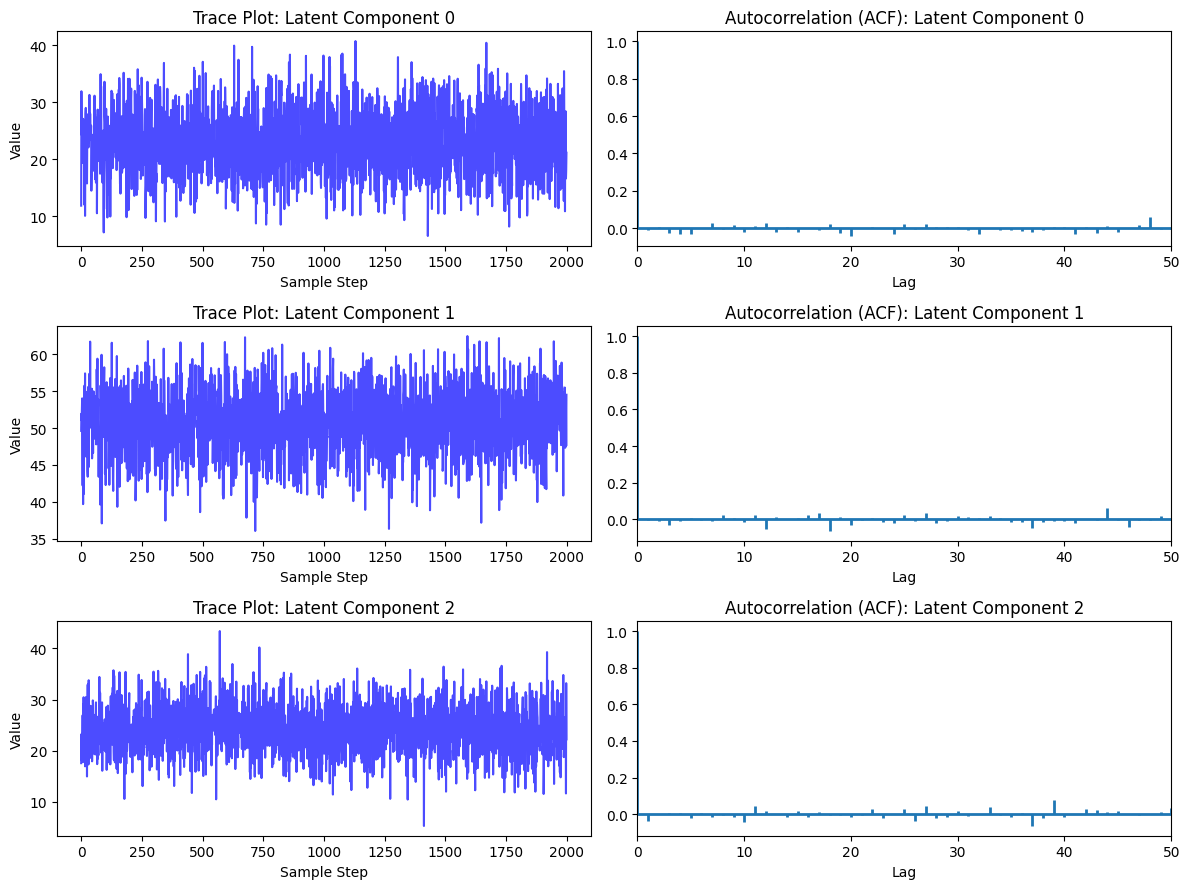

In [18]:
md.posterior_quality_check(slicing=0)

In [54]:
thawed_pos_consistent_frac, frozen_pos_consistent_frac, \
    bestsample_consistency, worstsample_consistency = md.posterior_predictive_check(beta=beta_posterior, n_samples=500)


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy.core.multiarray._reconstruct was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy.core.multiarray._reconstruct])` or the `torch.serialization.safe_globals([numpy.core.multiarray._reconstruct])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch